## <span style='color:green'>Predicting The Pax Load Factor For Depature Flights from DEHLI International Airport </span>
## Goals of the Project 
- The goals of the project is to study what factors affect Flight pax load , Find trends and patterns which will be used to produce a predictive Machine Learning Algarithm . 
- The end result of the project will be a ML Model that can be used in the Future to create predictions of Airlines based on important factors such as Airport Origin and International or Domestic Status . 
- At the end of the day , This project will be accessible via the `´Jupyter nbviewer`´ offering a possiblity of parametric turning for project users . 

## 1. Required Libraries & Functions

In [633]:
# Importing Python Libraries to be used In this project . 
import numpy  as np 
import pandas as pd 
from matplotlib import pyplot as plt
import seaborn as sns 
import dateutil.parser as parser 
from datetime import datetime # For converting dates to datetime 
from datetime import datetime, timedelta
import re # Importing regular expressions , a power language for matching regular expressions .
import matplotlib.pyplot as plt
%matplotlib inline
from pandas.tseries.offsets import *
from plotly import tools
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error


### 2. Fetching The Depature Data Frame for further Manipulation from Notebook

In [634]:
%store -r Feature_Selection_Depature
Feature_Selection_Depature.columns

Index(['Date', 'Day of week', 'Weekend (0/1)', 'Holiday (0/1)', 'Festival',
       'Overlap with Weekend', 'Extended weekend', 'boarded pax',
       'Original Airport', 'Destination airport', 'Depature Datetime',
       'Seat Capacity', 'traffic_type', 'Flight Number', 'Terminal',
       'Airline Code', 'PAr', 'Month', 'WN', 'Year'],
      dtype='object')

### 2.1 Calculating Airport Distribution in terms of Passangers
- The goal is to observe all airport with 0 registered total sum of passangers so that they can be eliminated

In [635]:
AirpotCount = Feature_Selection_Depature.groupby("Destination airport").agg({"boarded pax": "sum"})
AirpotCount = AirpotCount.rename(columns={"Destination  airport": "Destination  Airport", "boarded pax": "Boarded passengers"}).reset_index()
AC = AirpotCount.sort_values(by="Boarded passengers", ascending=True)

In [636]:
AC_Exclude=AC[AC["Boarded passengers"]==0.0]
Airports_to_exclude=AC_Exclude["Destination airport"].unique() # Finding those unique Airport Destinations that have 0 total passangers
Feature_Selection_Depature = Feature_Selection_Depature[~Feature_Selection_Depature["Destination airport"].isin(Airports_to_exclude)]

## 2.2 Cleaning Flight Number Data Columns
- This includes removing unwanted charaters 
- stripping out spaces and traillings 
- Converting them to a string Format 

In [637]:
# Replace multiple spaces between alphanumeric characters with a single space
Feature_Selection_Depature['Flight Number'] = Feature_Selection_Depature['Flight Number'].apply(lambda x: re.sub(r'(?<=[a-zA-Z])\s+(?=\d)|(?<=\d)\s+(?=[a-zA-Z])', ' ', x))
# Remove any remaining leading or trailing spaces
Feature_Selection_Depature['Flight Number'] = Feature_Selection_Depature['Flight Number'].str.strip()
Feature_Selection_Depature['Flight Number']=Feature_Selection_Depature['Flight Number'].str.replace("","")

In [638]:
def RemoveAD(Flight_Number):
    if Flight_Number[-1] == "D" or  Flight_Number[-1] == "A" or Flight_Number[-1] == "T":
        Flight_Number = Flight_Number[:-1]  # Remove the last character
    return Flight_Number

In [639]:
def Remove0(Flight_Number):
    if Flight_Number[-1] =="0":
        Flight_Number = Flight_Number[:-1]  # Remove the last character
    return Flight_Number

In [640]:
Feature_Selection_Depature['Flight Number']=Feature_Selection_Depature['Flight Number'].apply(RemoveAD)

In [641]:
Feature_Selection_Depature['Flight Number']=Feature_Selection_Depature['Flight Number'].apply(Remove0)

In [642]:
Feature_Selection_Depature["Flight Number"]=Feature_Selection_Depature["Flight Number"].str.replace(".00","")
Feature_Selection_Depature["Flight Number"]=Feature_Selection_Depature["Flight Number"].str.replace(".0","")
Feature_Selection_Depature["Flight Number"]=Feature_Selection_Depature["Flight Number"].str.replace("+","")
Feature_Selection_Depature["Flight Number"]=Feature_Selection_Depature["Flight Number"].str.replace(".","")

In [643]:
Feature_Selection_Depature= Feature_Selection_Depature[Feature_Selection_Depature['boarded pax'] != 0.0] 

In [644]:
flight_numbers =Feature_Selection_Depature["Flight Number"]
lengths = [len(re.sub(r'\s', '', flight_number)) for flight_number in flight_numbers]
Feature_Selection_Depature.loc[:,'FN_Length'] = Feature_Selection_Depature.loc[:,'Flight Number'].apply(lambda x: len(x))

In [645]:
Feature_Selection_Depature["FN_Length"].unique()

array([5, 6, 4, 7, 3], dtype=int64)

## 2.3 Cleaning Airline Data Columns
- Some Airlines do not have any significant amount of passangers 
- Some Airlines where wrongly written , misplaced and have to be corrected based on a specif iota convention

In [646]:
Feature_Selection_Depature.columns

Index(['Date', 'Day of week', 'Weekend (0/1)', 'Holiday (0/1)', 'Festival',
       'Overlap with Weekend', 'Extended weekend', 'boarded pax',
       'Original Airport', 'Destination airport', 'Depature Datetime',
       'Seat Capacity', 'traffic_type', 'Flight Number', 'Terminal',
       'Airline Code', 'PAr', 'Month', 'WN', 'Year', 'FN_Length'],
      dtype='object')

In [647]:
AirlineCount = Feature_Selection_Depature.groupby("Airline Code").agg({"boarded pax": "sum"})
AirlineCount = AirlineCount.rename(columns={"Airline Code": "Airline Code", "boarded pax": "Boarded passengers"}).reset_index()
Airline_CodeCount = AirlineCount.sort_values(by="Boarded passengers", ascending=True)

### 2.3.1 Calculating Mean For the Airlines and Calculating Standard Deviation
- The goal is to find the standard Deviation of the boarded Pax Per Airlines and use it to remove outliers for a cleaner Data Set 

In [648]:
Airline_CodeCount=Airline_CodeCount[Airline_CodeCount["Boarded passengers"]<=700]
Airline_CodeCount["Airline Code"].unique()

array(['IZ', 'IF', 'XC', 'PR', 'S9', 'GA', 'AH', 'OM', 'OV', 'Q2', 'UB'],
      dtype=object)

In [649]:
airline_to_exclude=Airline_CodeCount["Airline Code"].unique()
Feature_Selection_Depature = Feature_Selection_Depature[~Feature_Selection_Depature["Airline Code"].isin(airline_to_exclude)]

In [650]:
Feature_Selection_Depature.columns

Index(['Date', 'Day of week', 'Weekend (0/1)', 'Holiday (0/1)', 'Festival',
       'Overlap with Weekend', 'Extended weekend', 'boarded pax',
       'Original Airport', 'Destination airport', 'Depature Datetime',
       'Seat Capacity', 'traffic_type', 'Flight Number', 'Terminal',
       'Airline Code', 'PAr', 'Month', 'WN', 'Year', 'FN_Length'],
      dtype='object')

In [651]:
Feature_Selection_Depature_Domestic=Feature_Selection_Depature[['Date','boarded pax', 'Day of week', 'Weekend (0/1)', 'Holiday (0/1)',
       'Overlap with Weekend', 'Extended weekend',
       'Destination airport', 'Depature Datetime',
       'Seat Capacity', 'traffic_type', 'Flight Number', 'Terminal',
       'Airline Code', 'PAr', 'Month', 'WN', 'Year']]

## 2.4 Feature Exreaction 
This section will look at all the available Features and create more features in question to increase the correlation coefficient with the PAr values . More Features are extracted either through combining more than two virgin features or extracting out a feature subset from a specific feature such as `Date´

### 2.4.1 Categorizing the DS into seasons 

### Flight Seasonality

In [652]:
Feature_Selection_Domestic_gb=Feature_Selection_Depature_Domestic.groupby("Month").agg({"boarded pax":"sum"})
Feature_Selection_Domestic_gb.sort_values(by="boarded pax",ascending=False)

,boarded pax
Month,
December,11521543.0
October,10787177.0
November,10732631.0
September,10634528.0
August,10497112.0
July,10385528.0
June,10143702.0
March,9893653.0
January,9594659.0


In [653]:
def Seasons(Month):
    FirstBC = ["October", "December"] # stands for BestMontCombination
    SecondBM = ["November", "September"]
    ThirdBM = ["August", "July"]
    FouthBM =["June","March"]
    FifthBM=["January","February"]
    SixthBM=["May","April"]
    
    if Month in FirstBC:
        return 1
    elif Month in SecondBM:
        return 2
    elif Month in ThirdBM:
        return 3
    elif Month in FouthBM:
        return 4
    elif Month in FifthBM:
        return 5
    else:
        return 6

In [654]:
Feature_Selection_Depature_Domestic.loc[:,"Season"]=Feature_Selection_Depature_Domestic.loc[:,"Month"].apply(Seasons)

### 2.4.2 Creating a Domestic Feature of Time 
- This feature intends to classify time into Morning , Afternoon , Late evening and Late night 
- In this way, the decision tree algarithim will be able to make decisions fitting this priangle as well . Flight Data shows that pax often look at the time they are most likely to arrive at the destination before making decisions regarding making a booking . 

In [655]:
Feature_Selection_Depature_Domestic.columns

Index(['Date', 'boarded pax', 'Day of week', 'Weekend (0/1)', 'Holiday (0/1)',
       'Overlap with Weekend', 'Extended weekend', 'Destination airport',
       'Depature Datetime', 'Seat Capacity', 'traffic_type', 'Flight Number',
       'Terminal', 'Airline Code', 'PAr', 'Month', 'WN', 'Year', 'Season'],
      dtype='object')

In [656]:
Feature_Selection_Depature_Domestic["Depature Datetime"]=pd.to_datetime(Feature_Selection_Depature_Domestic["Depature Datetime"])
Feature_Selection_Depature_Domestic["Hour"]=Feature_Selection_Depature_Domestic["Depature Datetime"].dt.hour

In [657]:
Feature_Selection_Domestic_Hour = Feature_Selection_Depature_Domestic.groupby("Hour").agg({"boarded pax": "sum"})
Feature_Selection_Domestic_Hour.sort_values(by="boarded pax",ascending=False)
Feature_Selection_Depature_Domestic.head(2)

,Date,boarded pax,Day of week,Weekend (0/1),Holiday (0/1),Overlap with Weekend,Extended weekend,Destination airport,Depature Datetime,Seat Capacity,traffic_type,Flight Number,Terminal,Airline Code,PAr,Month,WN,Year,Season,Hour
0,2018-12-31,166.0,Monday,0,0,0,0,BLR,2018-12-31 05:50:00,186.0,D,G8113,T2,G8,0.892473,December,1,2018,1,5
1,2018-12-30,88.0,Sunday,1,0,1,1,PAT,2018-12-30 15:10:00,186.0,D,G8149,T2,G8,0.473118,December,52,2018,1,15


In [658]:
def TimeInterval(x):  
    x = int(x)  
    if x == 6 or x == 13:
        return 613
    elif x == 7 or x == 17:
        return 717
    elif x == 5 or x == 10:
        return 510
    elif x == 9 or x == 18:
        return 918
    elif x == 11 or x == 20:
        return 1120
    elif x == 16 or x == 21:
        return 1621
    elif x == 14 or x == 19:
        return 1419
    elif x == 8 or x == 12:
        return 812
    elif x == 4 or x == 15:
        return 415
    elif x == 2 or x == 23:
        return 223
    elif x == 3 or x ==22:
        return 322
    else:
        return 10  # For 0 to 5 hours    

### 2.4.3 Categorizing the time Period into night and Day 
- The goal of this category is to further study any relationships between day/Night and Passanger reaction . 
- Night time is from 21 hours upto 6 am 
- Day time is from 7 am till 8 pm 

In [659]:
def ND(x):
    x = int(x)  # Convert x to an integer
    if 7 <= x <= 21:
        return 1 
    else : 
        return 0 # Understanding pax flow between 7 to 21 uhrs and 10pm to 6 uhr . 

In [660]:
Feature_Selection_Depature_Domestic = Feature_Selection_Depature_Domestic.copy()
Feature_Selection_Depature_Domestic['Depature Datetime'] = pd.to_datetime(Feature_Selection_Depature_Domestic['Depature Datetime'],errors='coerce')

In [661]:
Feature_Selection_Depature_Domestic.loc[:,'Depature Datetime']=pd.to_datetime(Feature_Selection_Depature_Domestic.loc[:,'Depature Datetime'])

In [662]:
# Picking time from Arrival Datetime
Feature_Selection_Depature_Domestic["Time"]=Feature_Selection_Depature_Domestic["Depature Datetime"].dt.hour

In [663]:
# grouping the time into the 4 categories 
# This will be further removed for our RandomForest algarithm
Feature_Selection_Depature_Domestic = Feature_Selection_Depature_Domestic.copy()
Feature_Selection_Depature_Domestic.loc[:,"TIntervals"]=Feature_Selection_Depature_Domestic.loc[:,"Time"].apply(TimeInterval)

In [664]:
Feature_Selection_Depature_Domestic = Feature_Selection_Depature_Domestic.copy()
Feature_Selection_Depature_Domestic.loc[:,"DayNight"]=Feature_Selection_Depature_Domestic.loc[:,"Time"].apply(ND)

- `Day of the Week Code ´` This represents a specific Number given to each day of the week 
- `Original Airport´ `´This represents a code provided to the airport itself , each airport will be given a specific number 
- `Airline Code´` This represents a code provided to each of the Airlines . This will be further filtered out during the Random forest Algarithm 
- `Month Code´ `The Element of Month was also categorized given its such an important factor when pax are making flight bookins


In [665]:
Feature_Selection_Depature_Domestic = Feature_Selection_Depature_Domestic.copy()
Feature_Selection_Depature_Domestic.loc[:, "Day of week_Code"] = Feature_Selection_Depature_Domestic["Day of week"].astype("category").cat.codes
Feature_Selection_Depature_Domestic.loc[:, "Destination  Airport_Code"] = Feature_Selection_Depature_Domestic["Destination airport"].astype("category").cat.codes
Feature_Selection_Depature_Domestic.loc[:, "Airline Code_Code"] = Feature_Selection_Depature_Domestic["Airline Code"].astype("category").cat.codes
Feature_Selection_Depature_Domestic.loc[:, "Month_Code"] = Feature_Selection_Depature_Domestic["Month"].astype("category").cat.codes

### 2.4.4 Temporal Features
This feature will combine Time and Week features to create a unique timestamp hence elminating season aspects in additon the the Winter , Summmer , Spring and Autumn already stated features

In [666]:
Feature_Selection_Depature_Domestic["Temporal_F"]=Feature_Selection_Depature_Domestic["Day of week"].apply(str)+Feature_Selection_Depature_Domestic["Time"].apply(str)
Feature_Selection_Depature_Domestic["Temporal_Code"]=Feature_Selection_Depature_Domestic["Temporal_F"].astype("category").cat.codes
#Feature_Selection_Domestic["Temporal_Code"].unique()

### 2.4.5 Date Based Features
This section extracts out day of the year and day of the month , Week Number , Name of the Day 

In [667]:
Feature_Selection_Depature_Domestic["Date"]=pd.to_datetime(Feature_Selection_Depature_Domestic["Date"])
Feature_Selection_Depature_Domestic["MonthDay"] = Feature_Selection_Depature_Domestic["Date"].dt.day # this featre extract day of the month
Feature_Selection_Depature_Domestic["DayOfYear"]=Feature_Selection_Depature_Domestic["Date"].dt.dayofyear

In [668]:
Feature_Selection_Depature_Domestic['quarter'] = Feature_Selection_Depature_Domestic['Date'].dt.quarter
Feature_Selection_Depature_Domestic['quarter_Code']=Feature_Selection_Depature_Domestic['quarter'].astype("category").cat.codes

In [669]:
Feature_Selection_Depature_Domestic['DayWWekend']=Feature_Selection_Depature_Domestic["Day of week_Code"]+Feature_Selection_Depature_Domestic.loc[:, "Weekend (0/1)"]

### 2.6  Incoperating in the Flight Number Feature 

In [670]:
Feature_Selection_Depature_Domestic.loc[:, "Flight Number_Code"] = Feature_Selection_Depature_Domestic["Flight Number"].astype("category").cat.codes

In [671]:
##vlookup for Flight Numbers
FligtNumber_Vlookup =Feature_Selection_Depature_Domestic[["Flight Number","Flight Number_Code"]]
FligtNumber_Vlookup=FligtNumber_Vlookup.drop_duplicates()
FligtNumber_Vlookup

,Flight Number,Flight Number_Code
0,G8113,2209
1,G8149,2246
2,G8719,2463
3,G8423,2376
4,G8446,2383
...,...,...
899761,IX184,2695
899762,IX2773,2698
901131,IX1769,2691
901132,IX1789,2692


In [672]:
Feature_Selection_Depature_Domestic.loc[:,"Airportime"]=Feature_Selection_Depature_Domestic.loc[:,"Destination  Airport_Code"]+Feature_Selection_Depature_Domestic.loc[:,"Time"]
Feature_Selection_Depature_Domestic.loc[:,"Airportime_code"]=Feature_Selection_Depature_Domestic.loc[:,"Airportime"].astype("category").cat.codes

### 2.7 Categorize Cording of Airport 

In [673]:
AirportCode =Feature_Selection_Depature_Domestic[["Destination airport","Destination  Airport_Code"]]
AirportCode=AirportCode.drop_duplicates()
AirportCode

,Destination airport,Destination Airport_Code
0,BLR,27
1,PAT,160
2,AMD,7
3,HYD,87
4,BOM,28
...,...,...
836046,FAI,63
839260,SKD,183
845635,VDY,205
881237,DPS,56


In [674]:
Feature_Selection_Depature_Domestic.columns

Index(['Date', 'boarded pax', 'Day of week', 'Weekend (0/1)', 'Holiday (0/1)',
       'Overlap with Weekend', 'Extended weekend', 'Destination airport',
       'Depature Datetime', 'Seat Capacity', 'traffic_type', 'Flight Number',
       'Terminal', 'Airline Code', 'PAr', 'Month', 'WN', 'Year', 'Season',
       'Hour', 'Time', 'TIntervals', 'DayNight', 'Day of week_Code',
       'Destination  Airport_Code', 'Airline Code_Code', 'Month_Code',
       'Temporal_F', 'Temporal_Code', 'MonthDay', 'DayOfYear', 'quarter',
       'quarter_Code', 'DayWWekend', 'Flight Number_Code', 'Airportime',
       'Airportime_code'],
      dtype='object')

In [675]:
ML_Algarithm=Feature_Selection_Depature_Domestic[['Date', 'Day of week','Day of week_Code', 'Weekend (0/1)', 'Holiday (0/1)','Airline Code', 'PAr', 'WN', 'Year', 'Season', 'Time', 'TIntervals', 'DayNight','Month_Code', 'Temporal_Code', 'MonthDay', 'DayOfYear', 'quarter', 'DayWWekend','Flight Number_Code', 'Airportime', 'Destination  Airport_Code','Airportime_code','traffic_type']]

In [676]:
print(ML_Algarithm.shape)
ML_Algarithm.columns

(772320, 24)


Index(['Date', 'Day of week', 'Day of week_Code', 'Weekend (0/1)',
       'Holiday (0/1)', 'Airline Code', 'PAr', 'WN', 'Year', 'Season', 'Time',
       'TIntervals', 'DayNight', 'Month_Code', 'Temporal_Code', 'MonthDay',
       'DayOfYear', 'quarter', 'DayWWekend', 'Flight Number_Code',
       'Airportime', 'Destination  Airport_Code', 'Airportime_code',
       'traffic_type'],
      dtype='object')

### The goal of this supervised Machine Learning Project is to use combinations of different Feature sub-categorized into numbers is to predict Pax loads of Passanger ratio based on Airlines . 

In [677]:
ML_Algarithm.sort_values(by="Date",ascending=True)

,Date,Day of week,Day of week_Code,Weekend (0/1),Holiday (0/1),Airline Code,PAr,WN,Year,Season,...,Temporal_Code,MonthDay,DayOfYear,quarter,DayWWekend,Flight Number_Code,Airportime,Destination Airport_Code,Airportime_code,traffic_type
230534,2018-01-01,Monday,1,0,1,ZO,NaN,1,2018,5,...,47,1,1,1,1,3837,42,33,41,D
230602,2018-01-01,Monday,1,0,1,AI,0.827778,1,2018,5,...,32,1,1,1,1,1855,176,160,175,D
230603,2018-01-01,Monday,1,0,1,AI,0.934426,1,2018,5,...,26,1,1,1,1,1850,218,208,217,D
230605,2018-01-01,Monday,1,0,1,AI,0.741935,1,2018,5,...,29,1,1,1,1,1893,216,203,215,D
230606,2018-01-01,Monday,1,0,1,AI,0.928571,1,2018,5,...,46,1,1,1,1,1951,36,28,35,D
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
901644,2023-12-31,Sunday,3,1,0,6E,1.000000,52,2023,1,...,86,31,365,4,4,266,48,27,47,D
901642,2023-12-31,Sunday,3,1,0,6E,0.946237,52,2023,1,...,86,31,365,4,4,138,132,111,131,D
901640,2023-12-31,Sunday,3,1,0,SG,0.993289,52,2023,1,...,85,31,365,4,4,2974,107,87,106,D
901660,2023-12-31,Sunday,3,1,0,6E,0.994624,52,2023,1,...,88,31,365,4,4,417,189,166,188,D


## 2.8 Pearson Correlation Method 
The Pearson correlation coefficient (r) is the most common way of measuring a linear correlation. It is a number between –1 and 1 that measures the strength and direction of the relationship between two variables.
In our case, the dependent Variables are the Features and the Dependent one is the PAr or the label 

In [678]:
cor_pearson=ML_Algarithm[['Date', 'Weekend (0/1)', 'Holiday (0/1)', 'WN', 'Year', 'Season', 'TIntervals', 'DayNight',
       'Day of week_Code', 'Destination  Airport_Code', 'Month_Code','Temporal_Code', 'MonthDay', 'DayOfYear','quarter','DayWWekend','Flight Number_Code', 'Airportime', 'Airportime_code','PAr','Time']]
Pearson_correlation=cor_pearson.corr()
round(Pearson_correlation,2)

,Date,Weekend (0/1),Holiday (0/1),WN,Year,Season,TIntervals,DayNight,Day of week_Code,Destination Airport_Code,...,Temporal_Code,MonthDay,DayOfYear,quarter,DayWWekend,Flight Number_Code,Airportime,Airportime_code,PAr,Time
Date,1.00,0.00,-0.00,0.12,0.99,-0.09,0.01,-0.00,0.00,0.02,...,0.00,0.02,0.12,0.11,0.00,-0.01,0.02,0.02,0.02,0.01
Weekend (0/1),0.00,1.00,-0.00,0.01,0.00,-0.01,0.00,-0.00,-0.16,-0.00,...,-0.16,-0.01,0.01,0.01,0.07,-0.00,-0.00,-0.00,0.04,0.00
Holiday (0/1),-0.00,-0.00,1.00,-0.01,0.00,0.01,0.00,0.00,-0.01,-0.00,...,-0.01,-0.01,-0.03,-0.02,-0.01,0.00,0.00,0.00,-0.02,0.00
WN,0.12,0.01,-0.01,1.00,-0.01,-0.85,-0.01,-0.02,-0.00,-0.01,...,-0.00,0.08,0.97,0.95,-0.00,-0.01,-0.01,-0.01,0.01,-0.01
Year,0.99,0.00,0.00,-0.01,1.00,0.03,0.01,0.00,0.00,0.02,...,0.00,0.00,-0.02,-0.02,0.00,-0.01,0.02,0.02,0.02,0.01
Season,-0.09,-0.01,0.01,-0.85,0.03,1.00,0.01,0.01,0.01,0.01,...,0.01,-0.02,-0.87,-0.84,0.01,0.02,0.01,0.01,0.01,0.01
TIntervals,0.01,0.00,0.00,-0.01,0.01,0.01,1.00,0.58,0.00,-0.06,...,-0.01,-0.00,-0.01,-0.01,0.00,-0.01,-0.01,-0.01,0.04,0.53
DayNight,-0.00,-0.00,0.00,-0.02,0.00,0.01,0.58,1.00,0.00,-0.01,...,-0.05,-0.00,-0.02,-0.02,0.00,0.02,0.04,0.04,0.07,0.48
Day of week_Code,0.00,-0.16,-0.01,-0.00,0.00,0.01,0.00,0.00,1.00,0.00,...,0.99,0.01,-0.01,-0.01,0.97,-0.00,0.00,0.00,-0.03,0.00
Destination Airport_Code,0.02,-0.00,-0.00,-0.01,0.02,0.01,-0.06,-0.01,0.00,1.00,...,-0.01,-0.00,-0.01,-0.01,-0.00,-0.01,1.00,1.00,-0.01,-0.08


<Axes: title={'center': 'Heat Map showing the relation between both the Dependent and Independent Variables'}>

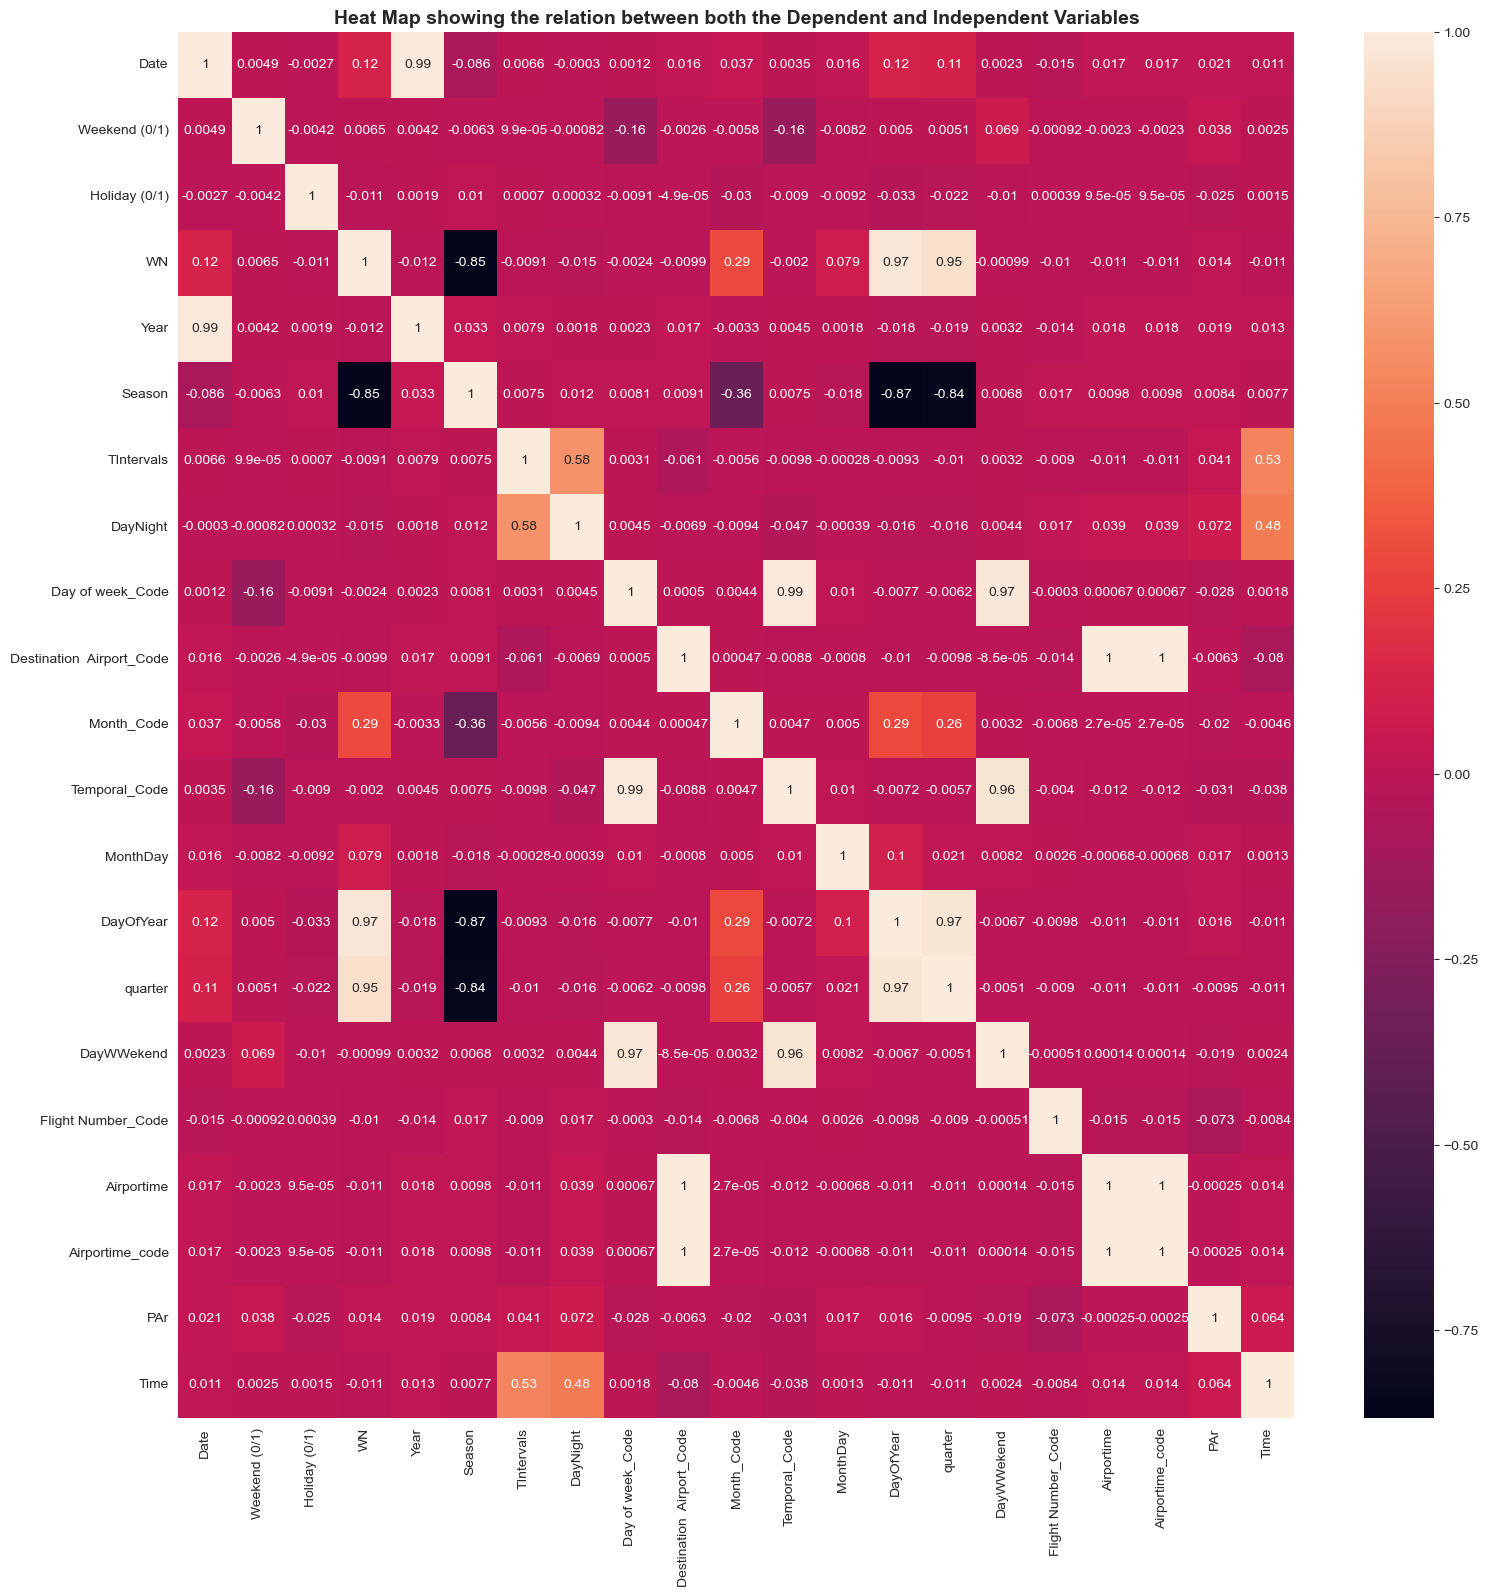

In [679]:
plt.figure(figsize=(18,18))
plt.title("Heat Map showing the relation between both the Dependent and Independent Variables", fontsize=14,fontweight="bold")
sns.heatmap(Pearson_correlation,annot=True)

In [680]:
a=abs(Pearson_correlation["PAr"])
result=a[a>0]
result=pd.DataFrame(result)
result.reset_index()
FR=result.rename(columns={"index":"Feature","PAr":"Coefficient Value"})
FR.sort_values(by="Coefficient Value",ascending=False)

,Coefficient Value
PAr,1.000000
Flight Number_Code,0.073128
DayNight,0.071770
Time,0.064249
TIntervals,0.041476
Weekend (0/1),0.037630
Temporal_Code,0.031050
Day of week_Code,0.027732
Holiday (0/1),0.024907
Date,0.021472


## <span style='color:green'>2.9 SELECTION OF FLIGHT TYPE </span>
It is worth noting that the ratio of the `Domestic`´ to the `International´`´ Flights is a 1:5 , this indicates that the model is most likely to make regressive decisions and predictions in the direction of the Domestic Flights . 
This level of biasness was removed by disecting out both Flight status and each running differently . 

In [681]:
ML_Algarithm["traffic_type"].value_counts() # The alagarithm will pivort most likely towards Domestic Flights 
# For that matter, I decided to drop them off and rather trin the algarithm based on Domestic and International Flights .

traffic_type
D    598325
I    173994
J         1
Name: count, dtype: int64

In [682]:
# Assuming Feature_Selection is your DataFrame

# Ask the user to input the traffic type (either "I" or "D")
traffic_type_input = input("Enter the traffic type (I for International, D for Domestic): ").upper()

# Check if the entered traffic type is valid
if traffic_type_input not in ["I", "D"]:
    print("Invalid input. Please enter either 'I' or 'D'.")
else:
    # Filter the DataFrame based on the user input
    ML_Algarithm_Status = ML_Algarithm[ML_Algarithm["traffic_type"] == traffic_type_input]

    # Display the result or perform further operations with Feature_Selection_Traffic_Type
    #print("Filtered DataFrame based on traffic type:")
    #print(Feature_Selection_Traffic_Type)


Enter the traffic type (I for International, D for Domestic): D


In [683]:
ML_Algarithm=ML_Algarithm_Status

## <span style='color:green'>3 SELECTION OF AIRLINE </span>

### Disecting only Different airlines 
- This is important since the algarithm can then be able to find patterns and trends only based on one algarithm with addition Engineering Features . 

In [684]:
ML_Algarithm["Airline Code"].value_counts()

Airline Code
6E    229749
AI     93501
UK     83908
SG     57430
G8     49071
9W     36877
I5     33235
9I      9137
QP      2955
S2      1206
IX      1059
ZO       184
ZZ         5
OD         2
UA         1
QR         1
WY         1
EY         1
BG         1
AA         1
Name: count, dtype: int64

### 3.1 Outliers 

In [685]:
ML_Algarithm['PAr'].dropna()
print(np.isfinite(ML_Algarithm['PAr']).all())
ML_Algarithm = ML_Algarithm[np.isfinite(ML_Algarithm['PAr'])] # Removing all rows with infinte values 

False


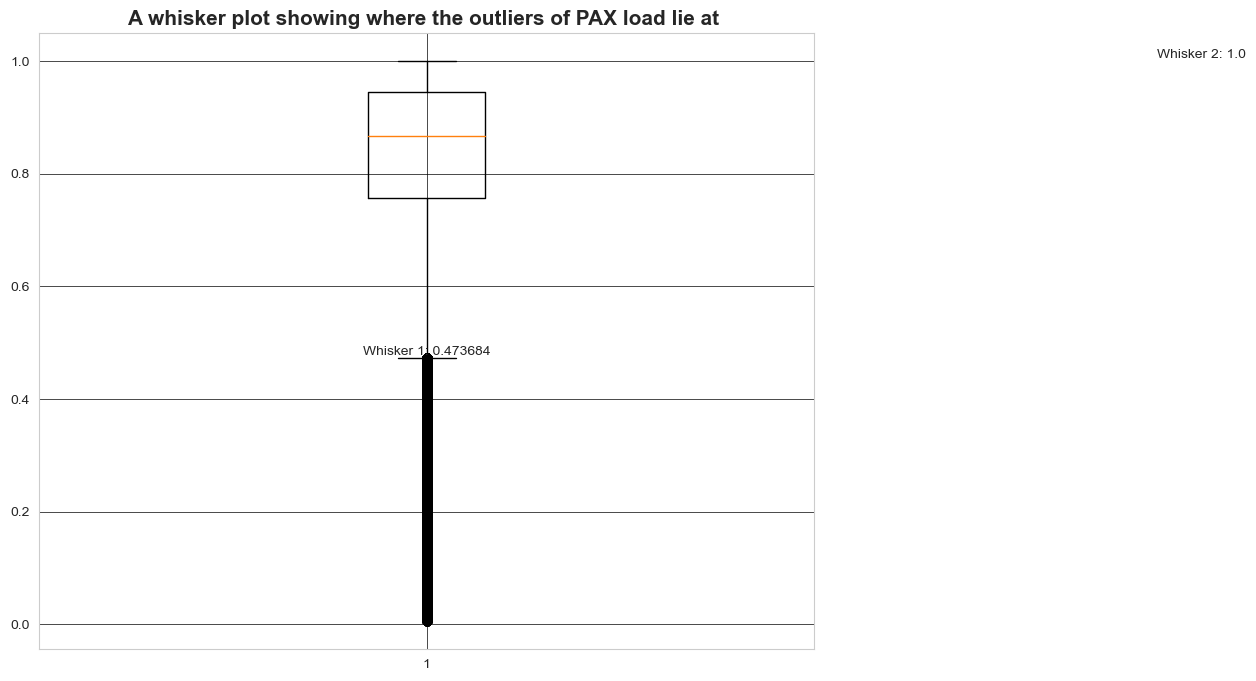

In [686]:
# Create a figure with a size of 10 by 8
plt.figure(figsize=(10, 8))

# Assuming DF_Date is your DataFrame
B = plt.boxplot(ML_Algarithm['PAr'])

# Extract the whisker values
whiskers = [item.get_ydata() for item in B['whiskers']]

# Label the whiskers and print their values
for i in range(len(whiskers)):
    plt.text(float(i + 1), whiskers[i][1], f'Whisker {i+1}: {whiskers[i][1]}', ha='center', va='bottom')

# Add black gridlines on all axes with a gridwidth of 0.5
plt.grid(color='black', linestyle='-', linewidth=0.5)
plt.title("A whisker plot showing where the outliers of PAX load lie at ", weight="bold", fontsize=15)

# Show the plot
plt.show()

#### Yearly Trend

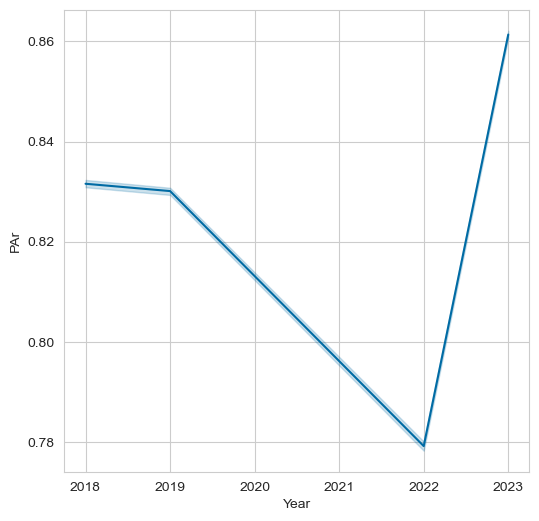

In [687]:
filtered_DF=ML_Algarithm[ML_Algarithm["Year"].isin([2018,2019, 2022, 2023])]
# only includeing years in the DF and removing not needed 
plt.figure(figsize=(6,6))
plt.grid(True)
sns.lineplot(x=filtered_DF['Year'],y=filtered_DF['PAr'])
plt.show()

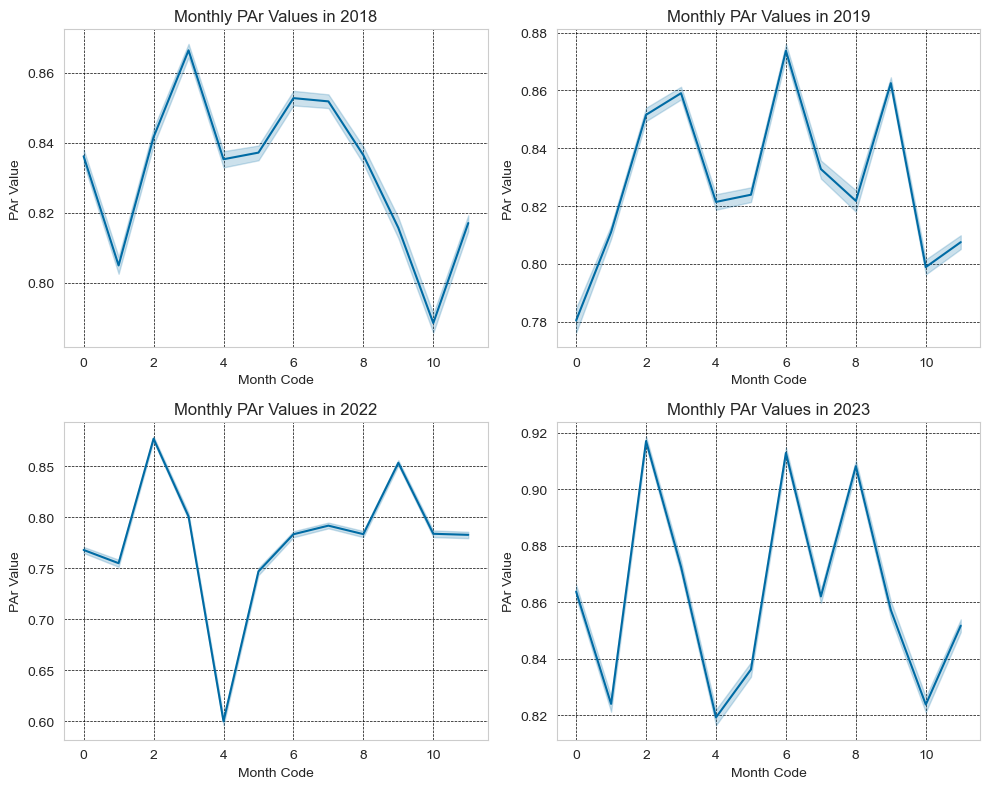

In [688]:
# Create a 2x2 subplot grid
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))

# Extract years to plot
years_to_plot = [2018, 2019, 2022, 2023]

# Iterate through subplots and plot data for each year
for i, year in enumerate(years_to_plot):
    filtered_DF = ML_Algarithm[ML_Algarithm["Year"].isin([year])]
    
    # Calculate subplot position in the 2x2 grid
    row = i // 2
    col = i % 2
    
    # Plotting the line graph on the current subplot
    sns.lineplot(x=filtered_DF['Month_Code'], y=filtered_DF['PAr'], ax=axes[row, col])
    
    # Adding labels to axes
    axes[row, col].set_xlabel('Month Code')
    axes[row, col].set_ylabel('PAr Value')
    
    # Adding a title to the subplot
    axes[row, col].set_title(f'Monthly PAr Values in {year}')
    
    # Changing gridline color to black
    axes[row, col].grid(True, color='black', linestyle='--', linewidth=0.5)

# Adjust layout for better spacing
plt.tight_layout()

# Show the subplots
plt.show()


In [689]:
Y_2018= ML_Algarithm[ML_Algarithm["Year"].isin([2018])]
Y_2019= ML_Algarithm[ML_Algarithm["Year"].isin([2019])]
Y_2022= ML_Algarithm[ML_Algarithm["Year"].isin([2022])]
Y_2023= ML_Algarithm[ML_Algarithm["Year"].isin([2023])]
Y_2023.columns

Index(['Date', 'Day of week', 'Day of week_Code', 'Weekend (0/1)',
       'Holiday (0/1)', 'Airline Code', 'PAr', 'WN', 'Year', 'Season', 'Time',
       'TIntervals', 'DayNight', 'Month_Code', 'Temporal_Code', 'MonthDay',
       'DayOfYear', 'quarter', 'DayWWekend', 'Flight Number_Code',
       'Airportime', 'Destination  Airport_Code', 'Airportime_code',
       'traffic_type'],
      dtype='object')

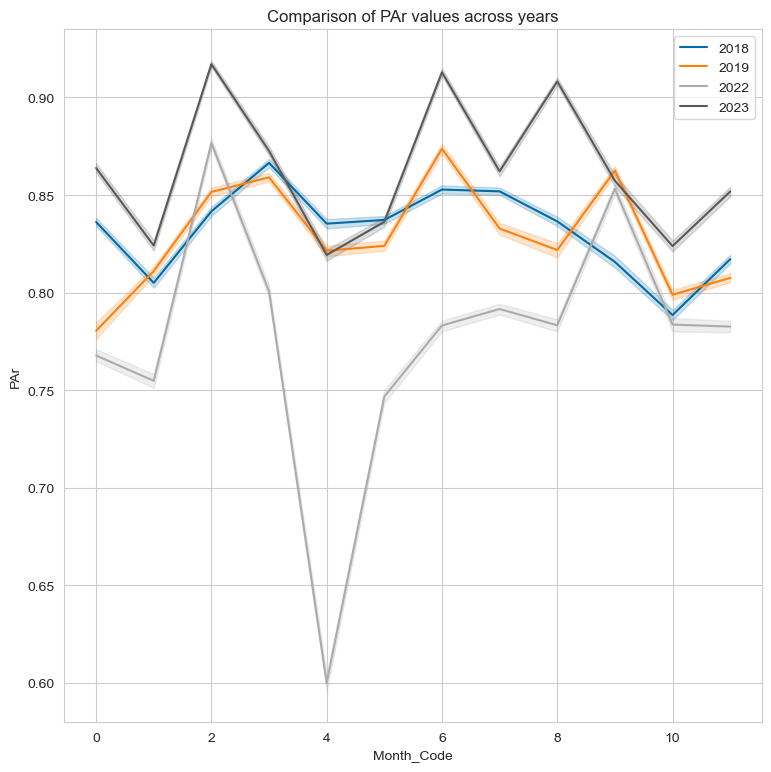

In [690]:
plt.figure(figsize=(9,9))

# Use lineplot for each year
sns.lineplot(x=Y_2018['Month_Code'], y=Y_2018['PAr'], label='2018')
sns.lineplot(x=Y_2019['Month_Code'], y=Y_2019['PAr'], label='2019')
sns.lineplot(x=Y_2022['Month_Code'], y=Y_2022['PAr'], label='2022')
sns.lineplot(x=Y_2023['Month_Code'], y=Y_2023['PAr'], label='2023')

# Add labels to the axes
plt.xlabel('Month_Code')
plt.ylabel('PAr')

# Add a legend to the plot
plt.legend()

# Add a title to the plot
plt.title('Comparison of PAr values across years')

# Add grid
plt.grid(True)

# Show the plot
plt.show()

### 3.1.1 Removing outliers
All values below the lower Bound and Above the upper bound where considered as outliers and where removed in the next step 

In [691]:
Bottom_outlier=whiskers[0][1]  
Top_outlier=whiskers[1][1]

In [692]:
print("Bottom Outliers is :",Top_outlier)
print("Bottom Outliers is :",Bottom_outlier)

Bottom Outliers is : 1.0
Bottom Outliers is : 0.473684


In [693]:
ML_Algarithm_Final=ML_Algarithm[(ML_Algarithm["PAr"]>Bottom_outlier)&(ML_Algarithm["PAr"]<Top_outlier)]
ML_Algarithm_Final.shape

(554144, 24)

#### 3.1.2 Checking Percentage of outliers 
Percentage of the total removed passangers in comparrison to the total Data Frame 

In [694]:
print(((len(ML_Algarithm)-len(ML_Algarithm_Final))/len(ML_Algarithm))*100)
ML_Algarithm_Final["Year"].value_counts()

6.830069590276529


Year
2018    159300
2023    136259
2022    131432
2019    127153
Name: count, dtype: int64

In [695]:
## Distrbiution of outliers 
Outliers=ML_Algarithm[(ML_Algarithm["PAr"]<Bottom_outlier)&(ML_Algarithm["PAr"]>Top_outlier)]
Outliers.shape

(0, 24)

## 4 Applying the Random-Forest-Regressor

In [696]:
ML_Algarithm_Final.columns

Index(['Date', 'Day of week', 'Day of week_Code', 'Weekend (0/1)',
       'Holiday (0/1)', 'Airline Code', 'PAr', 'WN', 'Year', 'Season', 'Time',
       'TIntervals', 'DayNight', 'Month_Code', 'Temporal_Code', 'MonthDay',
       'DayOfYear', 'quarter', 'DayWWekend', 'Flight Number_Code',
       'Airportime', 'Destination  Airport_Code', 'Airportime_code',
       'traffic_type'],
      dtype='object')

### 4.1 Selection Procedure in terms of Years 
This section involves disecting The Data Set into a Testing and Training Observations

In [697]:
Y2018 = ML_Algarithm_Final[ML_Algarithm_Final["Year"] == "2018"]
Y2019 = ML_Algarithm_Final[ML_Algarithm_Final["Year"] == "2019"]
Y2023_Sept = ML_Algarithm_Final[(ML_Algarithm_Final["Date"] >= "2022-05-01") & (ML_Algarithm_Final["Date"] <= "2023-09-30")]

In [698]:
DF_Date_Y181922 =pd.concat([Y2018,Y2019,Y2023_Sept]).reset_index(drop=True)
DF_Date_Y181922 = DF_Date_Y181922.drop(columns=["Airline Code"])

In [699]:
DF_Date_Test_Y2023 = ML_Algarithm_Final[(ML_Algarithm_Final["Date"] >= "2023-10-01") & (ML_Algarithm_Final["Date"] <= "2023-12-31")]
DF_Date_Test_Y2023 = DF_Date_Test_Y2023.drop(columns=["Airline Code"])

In [700]:
print("Data shape for the training set ",DF_Date_Y181922.shape)
print("Data shape for the testing set ",DF_Date_Test_Y2023.shape)

Data shape for the training set  (193155, 23)
Data shape for the testing set  (33788, 23)


In [701]:
XGB_Test=DF_Date_Test_Y2023
XGB_Train=DF_Date_Y181922

In [702]:
(len(DF_Date_Test_Y2023)/len(DF_Date_Y181922))*100

17.492687220108202

In [703]:
DF_Date_Test_Y2023.columns

Index(['Date', 'Day of week', 'Day of week_Code', 'Weekend (0/1)',
       'Holiday (0/1)', 'PAr', 'WN', 'Year', 'Season', 'Time', 'TIntervals',
       'DayNight', 'Month_Code', 'Temporal_Code', 'MonthDay', 'DayOfYear',
       'quarter', 'DayWWekend', 'Flight Number_Code', 'Airportime',
       'Destination  Airport_Code', 'Airportime_code', 'traffic_type'],
      dtype='object')

In [704]:
FR.sort_values(by="Coefficient Value",ascending=False)

,Coefficient Value
PAr,1.000000
Flight Number_Code,0.073128
DayNight,0.071770
Time,0.064249
TIntervals,0.041476
Weekend (0/1),0.037630
Temporal_Code,0.031050
Day of week_Code,0.027732
Holiday (0/1),0.024907
Date,0.021472


In [705]:
DF_Date_Y181922.columns
# This indicates that we have 365 days in the year 2023 

Index(['Date', 'Day of week', 'Day of week_Code', 'Weekend (0/1)',
       'Holiday (0/1)', 'PAr', 'WN', 'Year', 'Season', 'Time', 'TIntervals',
       'DayNight', 'Month_Code', 'Temporal_Code', 'MonthDay', 'DayOfYear',
       'quarter', 'DayWWekend', 'Flight Number_Code', 'Airportime',
       'Destination  Airport_Code', 'Airportime_code', 'traffic_type'],
      dtype='object')

In [706]:
DF_Date_Y181922=DF_Date_Y181922.groupby(['Date','Year','quarter',"Destination  Airport_Code","Temporal_Code",'Weekend (0/1)', 'WN','Season','Day of week_Code',
       'DayNight', 'Holiday (0/1)' ,'DayWWekend','TIntervals','Time','Flight Number_Code']).agg({"PAr":"mean"}).reset_index()
DF_Date_Y181922.columns

Index(['Date', 'Year', 'quarter', 'Destination  Airport_Code', 'Temporal_Code',
       'Weekend (0/1)', 'WN', 'Season', 'Day of week_Code', 'DayNight',
       'Holiday (0/1)', 'DayWWekend', 'TIntervals', 'Time',
       'Flight Number_Code', 'PAr'],
      dtype='object')

In [707]:
DF_Date_Y181922=DF_Date_Y181922.groupby(['Date','Year','quarter',"Destination  Airport_Code","Temporal_Code",'Weekend (0/1)', 'WN','Season','Day of week_Code',
       'DayNight', 'Holiday (0/1)' ,'DayWWekend','TIntervals','Time','Flight Number_Code']).agg({"PAr":"mean"}).reset_index()
DF_Date_Y181922

,Date,Year,quarter,Destination Airport_Code,Temporal_Code,Weekend (0/1),WN,Season,Day of week_Code,DayNight,Holiday (0/1),DayWWekend,TIntervals,Time,Flight Number_Code,PAr
0,2022-05-01,2022,2,7,72,1,17,6,3,0,0,4,10,0,131,0.537634
1,2022-05-01,2022,2,7,80,1,17,6,3,1,0,4,1621,16,2455,0.543011
2,2022-05-01,2022,2,7,81,1,17,6,3,1,0,4,717,17,971,0.908602
3,2022-05-01,2022,2,7,82,1,17,6,3,1,0,4,918,18,3330,0.751323
4,2022-05-01,2022,2,7,82,1,17,6,3,1,0,4,918,18,3763,0.706897
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
192581,2023-09-30,2023,3,208,66,1,39,2,2,0,0,3,415,4,632,0.913978
192582,2023-09-30,2023,3,209,54,1,39,2,2,1,0,3,1419,14,1877,0.945055
192583,2023-09-30,2023,3,209,58,1,39,2,2,1,0,3,918,18,1880,0.879121
192584,2023-09-30,2023,3,209,59,1,39,2,2,1,0,3,1419,19,703,0.924731


In [708]:
predictors=DF_Date_Y181922[['Date','Year','quarter',"Destination  Airport_Code","Temporal_Code",'Weekend (0/1)', 'WN','Season','Day of week_Code',
       'DayNight', 'Holiday (0/1)' ,'DayWWekend','TIntervals','Time','Flight Number_Code']]

target=DF_Date_Y181922[['PAr']]

In [709]:
#predictors.columns
predictors['Date'] = pd.to_datetime(predictors['Date']).astype('int64')

In [710]:
from sklearn.model_selection import train_test_split

# Split the data into training and cross-validation sets (80-20 split)
x_train, x_cv, y_train, y_cv = train_test_split(predictors, target, test_size=0.2, random_state=42)

# Ensure 'y_train' and 'y_cv' are 1D arrays
y_train = y_train.values.reshape(-1, 1)
y_cv = y_cv.values.reshape(-1, 1)

# Continue with the rest of your code for k-fold cross-validation
num_folds = 10
kf = KFold(n_splits=num_folds, shuffle=True, random_state=7)

# Checking the scores by using our function
algos = [LinearRegression, KNeighborsRegressor, RandomForestRegressor, Lasso, ElasticNet, DecisionTreeRegressor]
algorithm_scores = []
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score

def scores(algorithm, x_train, y_train, x_cv, y_cv):
    # Initialize the model
    model = algorithm()

    # Train the model on the training set
    model.fit(x_train, y_train)

    # Make predictions on the training set
    y_train_pred = model.predict(x_train)

    # Make predictions on the cross-validation set
    y_cv_pred = model.predict(x_cv)

    # Calculate R-squared scores
    train_score = r2_score(y_train, y_train_pred)
    cv_score = r2_score(y_cv, y_cv_pred)

    # Calculate Mean Squared Error
    mean_error_train = mean_squared_error(y_train, y_train_pred)
    mean_error_cv = mean_squared_error(y_cv, y_cv_pred)
    
    # Calculate the Adjusted R-sqaured scores 
    train_score_adjusted_r_squared = 1 - (1 - train_score) * (len(y_train) - 1) / (len(y_train) - x_train.shape[1] - 1)

    return train_score, train_score_adjusted_r_squared,cv_score, mean_error_cv

for algo in algos:
    avg_train_score, train_score_adjusted_r_squared, avg_cv_score, avg_mean_error = scores(algo, x_train.values, y_train, x_cv.values, y_cv)
    algorithm_scores.append((algo.__name__, avg_train_score, train_score_adjusted_r_squared, avg_cv_score, avg_mean_error))
    print(f'{algo.__name__} Average Training R-squared score: {avg_train_score}')
    print(f'{algo.__name__} Average Adjusted Training R-squared score: {train_score_adjusted_r_squared}')
    print(f'{algo.__name__} Average Cross-Validation R-squared score: {avg_cv_score}')
    print(f'{algo.__name__} Average Mean Error: {avg_mean_error}')

# Optionally, you can print or analyze the scores
print("Algorithm Scores:")
for algo_name, avg_train_score, train_score_adjusted_r_squared, avg_cv_score, avg_mean_error in algorithm_scores:
    print(f'{algo_name}:')
    print(f'  Average Training Score: {avg_train_score}')
    print(f'  Adjusted Training R-squared score: {train_score_adjusted_r_squared}')
    print(f'  Average Cross-Validation Score: {avg_cv_score}')
    print(f'  Average Mean Error: {avg_mean_error}')


LinearRegression Average Training R-squared score: 0.047828993828208044
LinearRegression Average Adjusted Training R-squared score: 0.04773628120459672
LinearRegression Average Cross-Validation R-squared score: 0.050184679865104664
LinearRegression Average Mean Error: 0.0156005748670701
KNeighborsRegressor Average Training R-squared score: 0.3532880742383696
KNeighborsRegressor Average Adjusted Training R-squared score: 0.3532251040796802
KNeighborsRegressor Average Cross-Validation R-squared score: 0.02822054376901073
KNeighborsRegressor Average Mean Error: 0.01596133252415755
RandomForestRegressor Average Training R-squared score: 0.9265207226751943
RandomForestRegressor Average Adjusted Training R-squared score: 0.9265135680185856
RandomForestRegressor Average Cross-Validation R-squared score: 0.47719059823096377
RandomForestRegressor Average Mean Error: 0.008587066391335555
Lasso Average Training R-squared score: 0.04135209336325252
Lasso Average Adjusted Training R-squared score: 

- As I have have evaluated, the ` Random-Forest-Regressor´`´ will be the best algorithm for our given dataset. So let’s run it and see, how it performs.

### 4.2 The Random Forest Regressor is being implemented here 

In [711]:
#Hypertuned Model
model = RandomForestRegressor(n_estimators=50, oob_score = True,n_jobs=3,random_state =42, min_samples_leaf =8,max_depth=4)
# in this case the program is running an amount of 10 trees 
# gini criterion : They are specifically choosen to maximize the information gain at each step 
#max sample of 0.5 means it will draw random subsamples with size equal to half of the training entire set . 

In [712]:
# Fitting the model on the training Data 
model.fit(x_train,y_train)

RandomForestRegressor(max_depth=4, min_samples_leaf=8, n_estimators=50,
                      n_jobs=3, oob_score=True, random_state=42)

### 4.3 Showing the Trees created

In [713]:
trees = model.estimators_
# Print the first tree for example
print(trees[0])

DecisionTreeRegressor(max_depth=4, max_features=1.0, min_samples_leaf=8,
                      random_state=1608637542)


In [714]:
predictors.columns

Index(['Date', 'Year', 'quarter', 'Destination  Airport_Code', 'Temporal_Code',
       'Weekend (0/1)', 'WN', 'Season', 'Day of week_Code', 'DayNight',
       'Holiday (0/1)', 'DayWWekend', 'TIntervals', 'Time',
       'Flight Number_Code'],
      dtype='object')

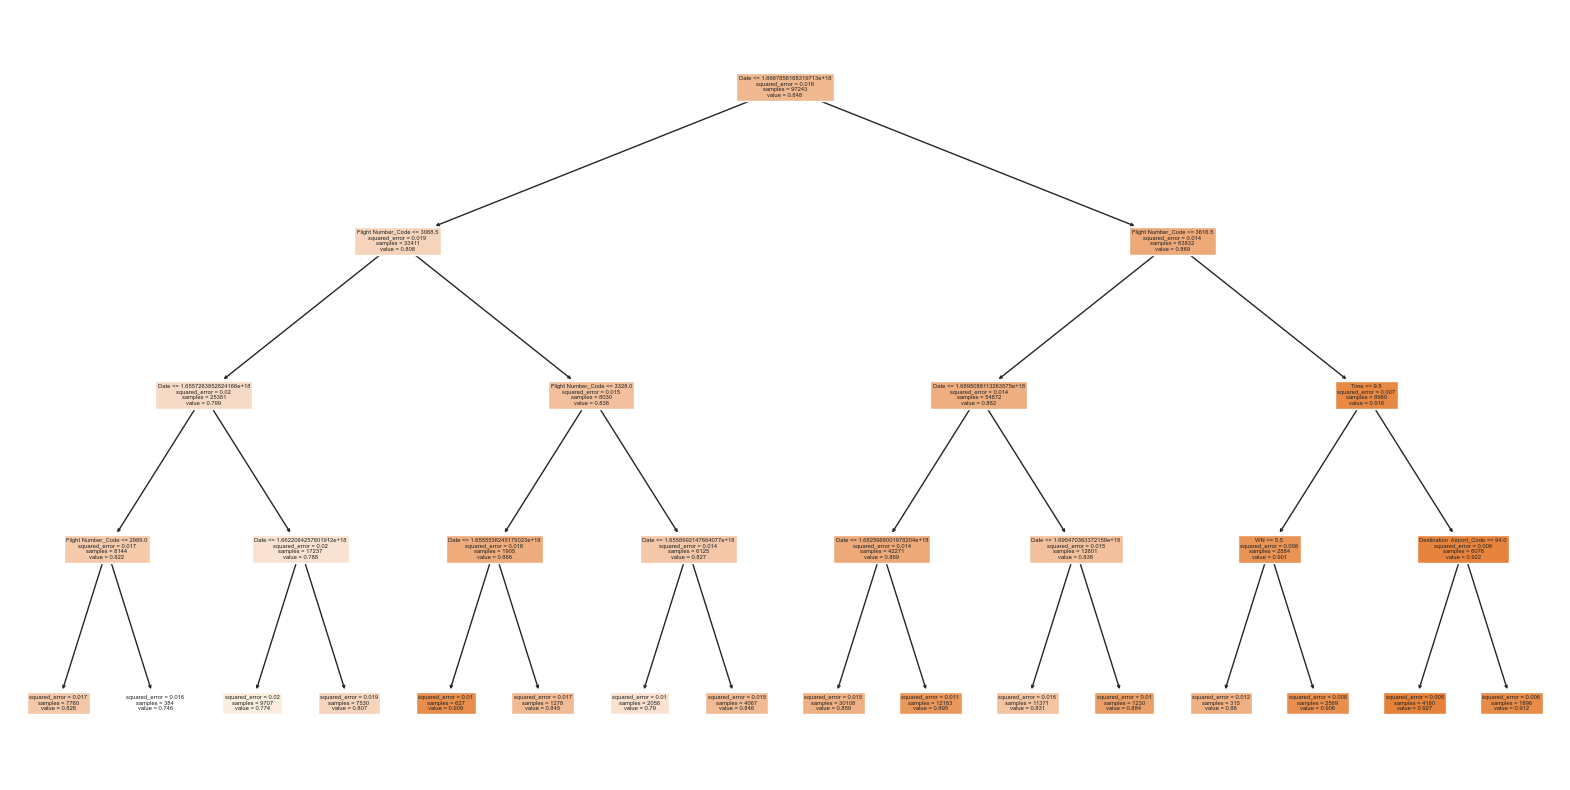

In [715]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

feature_names = ['Date','Year','quarter',"Destination  Airport_Code","Temporal_Code",'Weekend (0/1)', 'WN','Season','Day of week_Code',
       'DayNight', 'Holiday (0/1)' ,'DayWWekend','TIntervals','Time','Flight Number_Code']

# Assuming you have your data (X, y) to fit the model
# model.fit(X, y)

# Plot the first tree for example
plt.figure(figsize=(20, 10))
plot_tree(model.estimators_[0], filled=True, feature_names=feature_names)
plt.show()

In [716]:
test=DF_Date_Test_Y2023
test=test[['Date','Year','quarter',"Destination  Airport_Code","Temporal_Code",'Weekend (0/1)', 'WN','Season','Day of week_Code',
       'DayNight', 'Holiday (0/1)' ,'DayWWekend','TIntervals','Time','Flight Number_Code']]

In [717]:
test.columns

Index(['Date', 'Year', 'quarter', 'Destination  Airport_Code', 'Temporal_Code',
       'Weekend (0/1)', 'WN', 'Season', 'Day of week_Code', 'DayNight',
       'Holiday (0/1)', 'DayWWekend', 'TIntervals', 'Time',
       'Flight Number_Code'],
      dtype='object')

In [718]:
for column in test:
    test.loc[:,"Date"] = test.loc[:,"Date"].astype('int64')  # Convert datetime to numeric representation

In [719]:
pred=model.predict(test) # it is combining the other parameters and making decisions . 

In [720]:
test.loc[:,"Predicted PAr"]=pred.round(6)

In [721]:
test

,Date,Year,quarter,Destination Airport_Code,Temporal_Code,Weekend (0/1),WN,Season,Day of week_Code,DayNight,Holiday (0/1),DayWWekend,TIntervals,Time,Flight Number_Code,Predicted PAr
840285,1696118400000000000,2023,4,87,73,1,39,1,3,0,0,4,10,1,366,0.883153
840289,1696118400000000000,2023,4,27,89,1,39,1,3,0,0,4,322,3,156,0.883153
840293,1696118400000000000,2023,4,166,90,1,39,1,3,0,0,4,415,4,426,0.883153
840294,1696118400000000000,2023,4,7,90,1,39,1,3,0,0,4,415,4,780,0.883153
840295,1696118400000000000,2023,4,104,91,1,39,1,3,0,0,4,510,5,184,0.883153
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
902045,1703980800000000000,2023,4,7,95,1,52,1,3,1,0,4,918,9,287,0.884686
902046,1703980800000000000,2023,4,54,74,1,52,1,3,1,0,4,510,10,422,0.884686
902047,1703980800000000000,2023,4,187,92,1,52,1,3,0,0,4,613,6,520,0.883153
902048,1703980800000000000,2023,4,5,76,1,52,1,3,1,0,4,812,12,721,0.884686


In [722]:
DF_Date_Test_Y2023.columns

Index(['Date', 'Day of week', 'Day of week_Code', 'Weekend (0/1)',
       'Holiday (0/1)', 'PAr', 'WN', 'Year', 'Season', 'Time', 'TIntervals',
       'DayNight', 'Month_Code', 'Temporal_Code', 'MonthDay', 'DayOfYear',
       'quarter', 'DayWWekend', 'Flight Number_Code', 'Airportime',
       'Destination  Airport_Code', 'Airportime_code', 'traffic_type'],
      dtype='object')

In [723]:
DF_Date_Test_Y2023=DF_Date_Test_Y2023[['Date','Year','quarter',"Destination  Airport_Code","Temporal_Code",'Weekend (0/1)', 'WN','Season','Day of week_Code',
       'DayNight', 'Holiday (0/1)' ,'DayWWekend','TIntervals','Time','Flight Number_Code','PAr']]
DF_Date_Test_Y2023.shape

(33788, 16)

In [724]:
DF_Date_Test_Y2023=DF_Date_Test_Y2023.groupby(['Date', 'Year', 'quarter','Destination  Airport_Code', 'Temporal_Code',
       'Weekend (0/1)', 'WN', 'Season', 'Day of week_Code', 'DayNight',
       'Holiday (0/1)', 'DayWWekend', 'TIntervals', 'Time','Flight Number_Code']).agg({"PAr":"mean"}).reset_index()

In [725]:
test=test.groupby(['Date', 'Year', 'quarter','Destination  Airport_Code', 'Temporal_Code',
       'Weekend (0/1)', 'WN', 'Season', 'Day of week_Code', 'DayNight',
       'Holiday (0/1)', 'DayWWekend', 'TIntervals', 'Time','Flight Number_Code']).agg({"Predicted PAr":"mean"}).reset_index()

In [726]:
DF_Date_Test_Y2023["Date"]=DF_Date_Test_Y2023["Date"].apply(pd.to_datetime)
test["Date"]=test["Date"].apply(pd.to_datetime)

In [727]:
test

,Date,Year,quarter,Destination Airport_Code,Temporal_Code,Weekend (0/1),WN,Season,Day of week_Code,DayNight,Holiday (0/1),DayWWekend,TIntervals,Time,Flight Number_Code,Predicted PAr
0,2023-10-01,2023,4,5,95,1,39,1,3,1,0,4,918,9,721,0.884686
1,2023-10-01,2023,4,7,74,1,39,1,3,1,0,4,510,10,93,0.884686
2,2023-10-01,2023,4,7,77,1,39,1,3,1,0,4,613,13,894,0.884686
3,2023-10-01,2023,4,7,77,1,39,1,3,1,0,4,613,13,3773,0.928624
4,2023-10-01,2023,4,7,78,1,39,1,3,1,0,4,1419,14,1197,0.884686
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33783,2023-12-31,2023,4,203,94,1,52,1,3,1,0,4,812,8,353,0.884686
33784,2023-12-31,2023,4,206,92,1,52,1,3,0,0,4,613,6,1883,0.883153
33785,2023-12-31,2023,4,208,76,1,52,1,3,1,0,4,812,12,878,0.884686
33786,2023-12-31,2023,4,208,77,1,52,1,3,1,0,4,613,13,3642,0.918260


In [728]:
test.columns

Index(['Date', 'Year', 'quarter', 'Destination  Airport_Code', 'Temporal_Code',
       'Weekend (0/1)', 'WN', 'Season', 'Day of week_Code', 'DayNight',
       'Holiday (0/1)', 'DayWWekend', 'TIntervals', 'Time',
       'Flight Number_Code', 'Predicted PAr'],
      dtype='object')

### 4.4 Merging both values using shared columns : 
- 'Date', 'Weekend (0/1)', 'Holiday (0/1)', 'Day of week_Code','Original Airport_Code', 'Time_Code', 'Time', 'Month_Code',
       'Airportime_code', 'Season', 'WN'

In [729]:
test_predict=pd.merge(DF_Date_Test_Y2023,test,on=['Date', 'Year','quarter','Destination  Airport_Code',"Temporal_Code",'Weekend (0/1)', 'WN','Season','Day of week_Code',
       'DayNight', 'Holiday (0/1)' ,'DayWWekend','TIntervals','Time','Flight Number_Code'],
                      how="inner")

In [730]:
test_predict.columns

Index(['Date', 'Year', 'quarter', 'Destination  Airport_Code', 'Temporal_Code',
       'Weekend (0/1)', 'WN', 'Season', 'Day of week_Code', 'DayNight',
       'Holiday (0/1)', 'DayWWekend', 'TIntervals', 'Time',
       'Flight Number_Code', 'PAr', 'Predicted PAr'],
      dtype='object')

In [731]:
test_predict.shape

(33788, 17)

In [732]:
from sklearn.metrics import mean_squared_error
mse= mean_squared_error(test_predict["PAr"], test_predict["Predicted PAr"])
print(f'MSE: {mse}')

MSE: 0.012892604200427428


In [733]:
print("in terms of percentage , the Mean squared error is : ",  mse*100)

in terms of percentage , the Mean squared error is :  1.2892604200427429


In [734]:
test_predict.tail(10)
##Studing Error and how best we can take care of it 

,Date,Year,quarter,Destination Airport_Code,Temporal_Code,Weekend (0/1),WN,Season,Day of week_Code,DayNight,Holiday (0/1),DayWWekend,TIntervals,Time,Flight Number_Code,PAr,Predicted PAr
33778,2023-12-31,2023,4,203,75,1,52,1,3,1,0,4,1120,11,3615,0.908537,0.884779
33779,2023-12-31,2023,4,203,77,1,52,1,3,1,0,4,613,13,180,0.844086,0.884686
33780,2023-12-31,2023,4,203,77,1,52,1,3,1,0,4,613,13,3608,0.890244,0.884779
33781,2023-12-31,2023,4,203,81,1,52,1,3,1,0,4,717,17,199,0.801075,0.884686
33782,2023-12-31,2023,4,203,92,1,52,1,3,0,0,4,613,6,182,0.865591,0.883153
33783,2023-12-31,2023,4,203,94,1,52,1,3,1,0,4,812,8,353,0.930108,0.884686
33784,2023-12-31,2023,4,206,92,1,52,1,3,0,0,4,613,6,1883,0.894444,0.883153
33785,2023-12-31,2023,4,208,76,1,52,1,3,1,0,4,812,12,878,0.987069,0.884686
33786,2023-12-31,2023,4,208,77,1,52,1,3,1,0,4,613,13,3642,0.951220,0.918260
33787,2023-12-31,2023,4,209,81,1,52,1,3,1,0,4,717,17,682,0.956989,0.884686


## 5  post-processing Technique to reduce the MAE of the model: 
 The goal of this technique is to balance out the high differences between the predicted and actualy pAr differences. 
 The adjustment is applied to the predicted values (Predicted PAr) based on the mean difference between the predicted and    actual values. The goal is to iteratively refine the predictions so that the mean absolute error (MAE) between the adjusted predictions and the actual values becomes closer to the target MAE.

In [735]:
test_predict["Difference"]=test_predict["Predicted PAr"]-test_predict["PAr"]

## 5.1 Applying the Mininimize post Machine Learning Algarithm

In [736]:
from sklearn.metrics import mean_absolute_error
from scipy.optimize import minimize_scalar

# Calculate the mean of the differences
mean_difference = test_predict['Difference'].mean()

# Initial evaluation
mae_original = mean_absolute_error(test_predict['PAr'], test_predict['Predicted PAr'])

# Define the objective function for optimization
def objective_function(adjustment_value):
    adjusted_predictions = test_predict['Predicted PAr'] + adjustment_value * mean_difference
    return mean_absolute_error(test_predict['PAr'], adjusted_predictions)

# Use optimization to find the optimal adjustment value
result = minimize_scalar(objective_function)
optimal_adjustment_value = result.x

# Adjust the predicted values with the optimal adjustment value
test_predict['Optimal Adjusted Predicted PAr'] = test_predict['Predicted PAr'] + optimal_adjustment_value * mean_difference

# Evaluate the performance of the adjusted predictions
mae_optimal_adjusted = mean_absolute_error(test_predict['PAr'], test_predict['Optimal Adjusted Predicted PAr'])

print(f'Optimal Adjustment Value: {optimal_adjustment_value}')
print(f'MAE (Optimal Adjusted Predictions): {mae_optimal_adjusted}')


Optimal Adjustment Value: 2.091271683057385
MAE (Optimal Adjusted Predictions): 0.08290434231103172


In [737]:
Not_adjusted_mae=mean_absolute_error(test_predict["PAr"],test_predict['Predicted PAr'])
predicted_mea_optimal=mean_absolute_error(test_predict["PAr"],test_predict['Optimal Adjusted Predicted PAr'])

In [738]:
percentage_increase = ((predicted_mea_optimal - Not_adjusted_mae) / Not_adjusted_mae) * 100
print("Iterative process, absolute error has been increased by:", percentage_increase,"%")

Iterative process, absolute error has been increased by: -3.1381637346950964 %


## 5.2 Reverting Back the Model

In [739]:
test_predict=test_predict[["Date","quarter",'Destination  Airport_Code','Flight Number_Code',"Weekend (0/1)","Season","Day of week_Code","Holiday (0/1)","TIntervals","PAr","Predicted PAr","Optimal Adjusted Predicted PAr","WN"]]
test_predict.shape

(33788, 13)

### Reverting back the Time interval 

In [740]:
def time_interval_convert(x):
    x = int(x)  
    if x == 613:
        return "6 am | 1 pm"
    elif x == 717:
        return "7 am | 5 pm"
    elif x == 510:
        return "5 am | 10 am"
    elif x == 918:
        return "9 am | 6 pm"
    elif x == 1120:
        return "11 am | 8 pm"
    elif x == 1621:
        return "4 pm | 9 pm"
    elif x == 1419:
        return "2 pm | 7 pm"
    elif x == 812:
        return "8 am | 12 MD"
    elif x == 415:
        return "4 am | 3 pm"
    elif x == 223:
        return "2 am | 11 pm"
    elif x == 322:
        return "3 am | 22 pm"
    else:
        return "1 am | 12 MN"

In [741]:
test_predict["Time Slot"]=test_predict["TIntervals"].apply(time_interval_convert)

### Reverting back the season Feature

In [742]:
def Seasons_revert(Month):
    if Month == 1:
        return "October or December"
    elif Month == 2:
        return "November or September"
    elif Month == 3:
        return "August or July"
    elif Month == 4:
        return "June or March"
    elif Month == 5:
        return "January or February"
    else:
        return "May or April"

In [743]:
test_predict["Season Name"]=test_predict["Season"].apply(Seasons_revert)

### Week Code conversion

In [744]:
DWCodeConversion=ML_Algarithm[['Day of week','Day of week_Code']]
DWCodeConversion=DWCodeConversion.drop_duplicates()

In [745]:
test_predict.shape

(33788, 15)

In [746]:
test_predict=pd.merge(test_predict,DWCodeConversion,on="Day of week_Code",how="inner")

In [747]:
test_predict.columns

Index(['Date', 'quarter', 'Destination  Airport_Code', 'Flight Number_Code',
       'Weekend (0/1)', 'Season', 'Day of week_Code', 'Holiday (0/1)',
       'TIntervals', 'PAr', 'Predicted PAr', 'Optimal Adjusted Predicted PAr',
       'WN', 'Time Slot', 'Season Name', 'Day of week'],
      dtype='object')

  
# <span style='color:green'>Model Improvement </span>
XGBoost provides built-in support for L1 (Lasso) and L2 (Ridge) regularization, which helps prevent overfitting by penalizing complex models. Random Forest, while having mechanisms to combat overfitting like bootstrapping and feature randomization, does not have the same level of explicit regularization.

XGBoost is an implementation of gradient boosting, which builds trees sequentially, each correcting errors made by the previous ones. This can lead to a more precise and accurate model.Random Forest, on the other hand, builds trees independently and combines their predictions through averaging (classification) or averaging-weighted voting (regression).

## 6. Using the XGBoost and GridSearch Algarithm

In [748]:
print("Shape of our training Data Set " , XGB_Train.shape)
print("Shape is of the testing Data Set:" ,XGB_Test.shape)

Shape of our training Data Set  (193155, 23)
Shape is of the testing Data Set: (33788, 23)


In [749]:
pip install xgboost

In [750]:
from xgboost import plot_importance, plot_tree
from warnings import filterwarnings
from sklearn.model_selection import GridSearchCV
import xgboost as xgb
filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize']=(20,10) # for graphs styling
plt.style.use('tableau-colorblind10') # for graph stying

In [751]:
XGB_Train.columns

Index(['Date', 'Day of week', 'Day of week_Code', 'Weekend (0/1)',
       'Holiday (0/1)', 'PAr', 'WN', 'Year', 'Season', 'Time', 'TIntervals',
       'DayNight', 'Month_Code', 'Temporal_Code', 'MonthDay', 'DayOfYear',
       'quarter', 'DayWWekend', 'Flight Number_Code', 'Airportime',
       'Destination  Airport_Code', 'Airportime_code', 'traffic_type'],
      dtype='object')

In [752]:
XGB_Train['Date'] = pd.to_datetime(XGB_Train['Date']).astype('int64')
XGB_Train['Date'].dtype

dtype('int64')

In [753]:
X_train=XGB_Train[['Date','quarter',"Destination  Airport_Code", 'Temporal_Code', 'Weekend (0/1)', 'WN', 'Season',
       'Day of week_Code', 'DayNight', 'Holiday (0/1)', 'DayWWekend',
       'TIntervals','Flight Number_Code']]
y_train=XGB_Train[['PAr']]

In [754]:
XGB_Test['Date'] = pd.to_datetime(XGB_Test['Date']).astype('int64')
XGB_Test['Date'].dtype

dtype('int64')

In [755]:
X_test=XGB_Test[['Date','quarter',"Destination  Airport_Code", 'Temporal_Code', 'Weekend (0/1)', 'WN', 'Season',
       'Day of week_Code', 'DayNight', 'Holiday (0/1)', 'DayWWekend',
       'TIntervals','Flight Number_Code']]
y_test=XGB_Test[["PAr"]]

In [756]:
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import r2_score, mean_absolute_error
import xgboost as xgb
import numpy as np

# A parameter grid for XGBoost
params = {
    'min_child_weight': [5],# [4, 5,6]
    'gamma': [0.01],# it was initially on a longer range 
    'subsample': [0.4],
    'colsample_bytree': [0.4,0.5,0.6],#[i / 10.0 for i in range(3, 5)]
    'max_depth': [5],
    'learning_rate': [0.2],# Without many constrains, the model can quickly fit or over fit hence reducing its possiblity through the learning rate . 
    'n_estimators': [150],
    'reg_alpha': [0, 0.001, 0.01, 0.1, 1, 10,20],# Increasing this value will make the model more conservative L2 regularization on weights 
    'reg_lambda': [0, 0.001, 0.01, 0.1, 1, 10,20],# L1 regularization term on weights .. 
    'scale_pos_weight': [1]  
    #max_features='sqrt'
}

# Initialize XGB
xgb_reg = xgb.XGBRegressor(nthread=-1, objective='reg:squarederror')

# Set up KFold cross-validation with k=5
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Initialize GridSearchCV with cross-validation
grid = GridSearchCV(xgb_reg, params, cv=kfold)
grid.fit(X_train, y_train)

# Get the best estimator from GridSearchCV
gridcv_xgb = grid.best_estimator_

# Predict on the test set
y_pred = gridcv_xgb.predict(X_test)

# Calculate R2 score
r2 = r2_score(y_test, y_pred)
print(f'R2 Score: {r2}')

# Calculate Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, y_pred)
print(f'Mean Absolute Error: {mae}')

# Additional Information: Print the best hyperparameters found by GridSearchCV
print("Best Hyperparameters:", grid.best_params_)

print(r2_score(y_test, gridcv_xgb.predict(X_test)))

R2 Score: 0.058680195332850404
Mean Absolute Error: 0.07904943727979945
Best Hyperparameters: {'colsample_bytree': 0.6, 'gamma': 0.01, 'learning_rate': 0.2, 'max_depth': 5, 'min_child_weight': 5, 'n_estimators': 150, 'reg_alpha': 0.001, 'reg_lambda': 1, 'scale_pos_weight': 1, 'subsample': 0.4}
0.058680195332850404


In [757]:
import xgboost as xgb
from sklearn.metrics import r2_score, mean_absolute_error

# Initialize XGBRegressor with the best hyperparameters
best_xgb_model = xgb.XGBRegressor(
    min_child_weight=gridcv_xgb.min_child_weight,
    gamma=gridcv_xgb.gamma,
    subsample=gridcv_xgb.subsample,
    colsample_bytree=gridcv_xgb.colsample_bytree,
    max_depth=gridcv_xgb.max_depth,
    learning_rate=gridcv_xgb.learning_rate,
    n_estimators=gridcv_xgb.n_estimators,
    scale_pos_weight=gridcv_xgb.scale_pos_weight,
    reg_alpha=gridcv_xgb.reg_alpha,
    reg_lambda=gridcv_xgb.reg_lambda,
    
    nthread=-1,
    objective='reg:squarederror'
)

# Train the model on the entire training dataset
best_xgb_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = best_xgb_model.predict(X_test)

# Evaluate the performance of the final model
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f'Final R2 Score: {r2}')
print(f'Final Mean Absolute Error: {mae}')

Final R2 Score: 0.058680195332850404
Final Mean Absolute Error: 0.07904943727979945


In [758]:
XGB_Test['Predicted PAr'] = y_pred

## 6.1 Feature Importances
- This is a metric that simply sums up how many times each feature is split on.
- It shows that Week Number was used so much often to split the trees, followed by the TIntervals and lastly the Seasons 

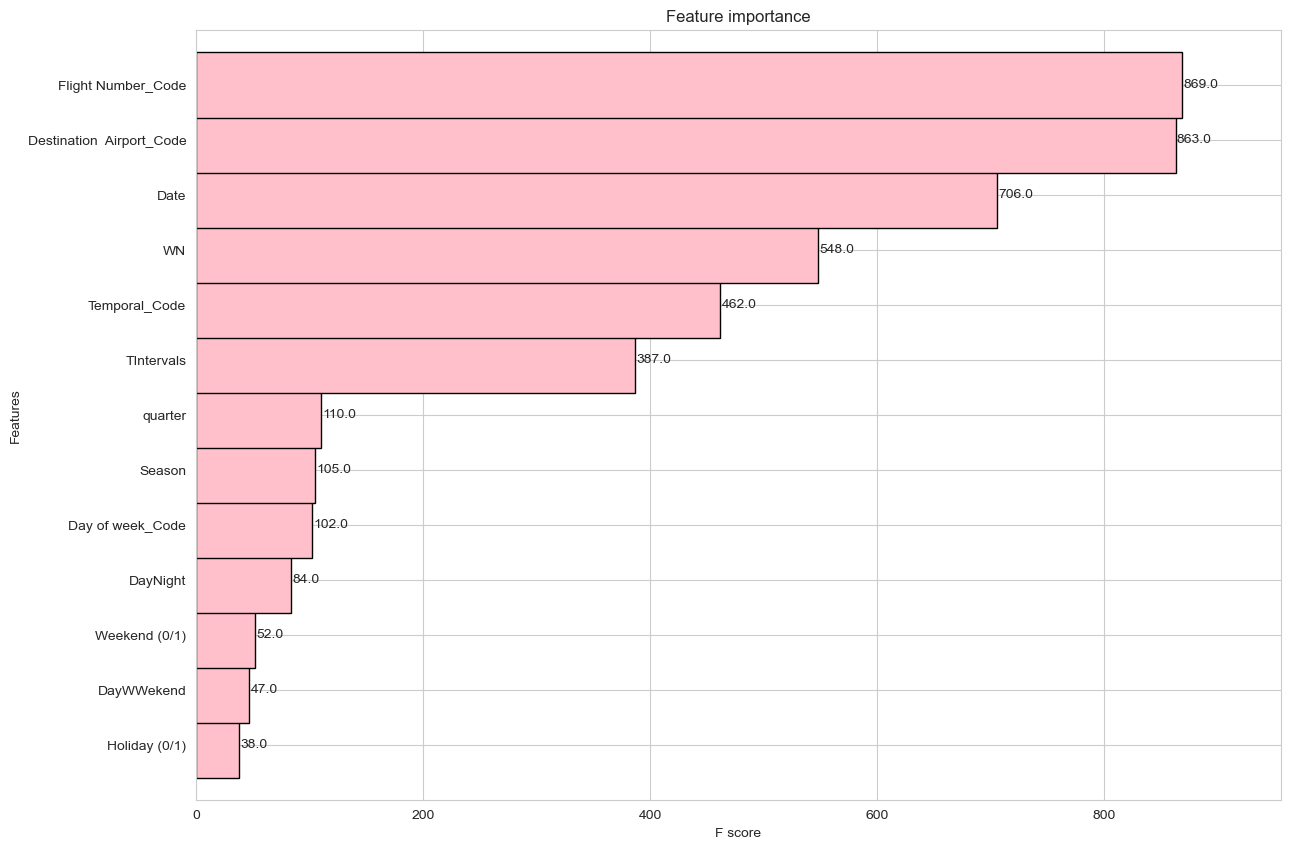

In [759]:
from xgboost import plot_importance
plt.rcParams["figure.figsize"] = (14,10)
plot_importance(best_xgb_model, height=1.2,edgecolor="black",color="pink")
plt.savefig(r"C:\Users\enock.mugabi\AOBD_Historical_Data\DELI Pictures\Feature_Importance.png")
plt.show()

In [760]:
XGB_Test.columns

Index(['Date', 'Day of week', 'Day of week_Code', 'Weekend (0/1)',
       'Holiday (0/1)', 'PAr', 'WN', 'Year', 'Season', 'Time', 'TIntervals',
       'DayNight', 'Month_Code', 'Temporal_Code', 'MonthDay', 'DayOfYear',
       'quarter', 'DayWWekend', 'Flight Number_Code', 'Airportime',
       'Destination  Airport_Code', 'Airportime_code', 'traffic_type',
       'Predicted PAr'],
      dtype='object')

In [761]:
from sklearn.metrics import mean_absolute_error

# Assuming XGB_Test is a DataFrame containing columns "PAr" and "Predicted PAr" for XGBoost
xgboost_mae = mean_absolute_error(XGB_Test["PAr"], XGB_Test["Predicted PAr"])
print("Mean Absolute Error for XGBoost algorithm is:", xgboost_mae)

# Assuming test_predict is a DataFrame containing columns "PAr" and "Predicted PAr" for RandomForestRegressor
random_forest_mae = mean_absolute_error(test_predict["PAr"], test_predict["Predicted PAr"])
print("Mean Absolute Error for RandomForestRegressor algorithm is:", random_forest_mae)


Mean Absolute Error for XGBoost algorithm is: 0.07904943727979945
Mean Absolute Error for RandomForestRegressor algorithm is: 0.08559030626257842


In [762]:
XGB_Test["WN"].unique()

<IntegerArray>
[39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52]
Length: 14, dtype: UInt32

In [763]:
XGB_Test["Date"]=pd.to_datetime(XGB_Test["Date"])

In [764]:
XGB_Test=XGB_Test.groupby(["Date","WN","Time","TIntervals",'Destination  Airport_Code','Flight Number_Code']).agg({"PAr":"mean","Predicted PAr":"mean"}).reset_index()
#XGB_Test.to_excel(r"C:\Users\enock.mugabi\AOBD_Historical_Data\Investigations\XGB_Test.xlsx")

In [765]:
XGB_Test_42=XGB_Test[XGB_Test["WN"]==41]
print(XGB_Test_42.shape)
XGB_Test_43=XGB_Test[XGB_Test["WN"]==42]
print(XGB_Test_43.shape)
XGB_Test_44=XGB_Test[XGB_Test["WN"]==43]
print(XGB_Test_44.shape)
XGB_Test_45=XGB_Test[XGB_Test["WN"]==44]
print(XGB_Test_45.shape)

(2763, 8)
(2685, 8)
(2632, 8)
(2647, 8)


In [766]:
def time_interval_convert(x):
    x = int(x)  
    if x == 613:
        return "6 am | 1 pm"
    elif x == 717:
        return "7 am | 5 pm"
    elif x == 510:
        return "5 am | 10 am"
    elif x == 918:
        return "9 am | 6 pm"
    elif x == 1120:
        return "11 am | 8 pm"
    elif x == 1621:
        return "4 pm | 9 pm"
    elif x == 1419:
        return "2 pm | 7 pm"
    elif x == 812:
        return "8 am | 12 MD"
    elif x == 415:
        return "4 am | 3 pm"
    elif x == 223:
        return "2 am | 11 pm"
    elif x == 322:
        return "3 am | 22 pm"
    else:
        return "1 am | 12 MN"

In [767]:
XGB_Test["Time Interval"]= XGB_Test["TIntervals"].apply(time_interval_convert)
XGB_Test.shape

(33788, 9)

In [768]:
XGB_Test['Day of week'] = XGB_Test["Date"].dt.day_name()

In [769]:
XGB_Test['Destination  Airport_Code'].unique()

array([ 33,  28,  87,   7, 110, 166,  27,  11,  17,  41,  70, 108, 151,
       208,  16,  50,  68,  90,  97, 103, 104, 111, 139, 187,  22,  38,
        47,  51,  98, 137, 174, 185, 206, 209,  48,  72,  92, 106, 159,
        54,  71, 102, 160, 164, 203,   5, 107, 112, 169, 194,  73,  49,
        96,  99,  76, 129, 177,  18,  46,  69, 117, 199, 100, 171,  86,
       118,  81,  32, 198, 133,  80, 119, 181, 109, 116, 101,  25, 122,
       120,   4,  95,  29, 184, 193,  13], dtype=int16)

In [770]:
print(XGB_Test.columns)
print(AirportCode.columns)

Index(['Date', 'WN', 'Time', 'TIntervals', 'Destination  Airport_Code',
       'Flight Number_Code', 'PAr', 'Predicted PAr', 'Time Interval',
       'Day of week'],
      dtype='object')
Index(['Destination airport', 'Destination  Airport_Code'], dtype='object')


In [771]:
XGB_Test = pd.merge(XGB_Test, AirportCode, left_on='Destination  Airport_Code', right_on='Destination  Airport_Code', how='inner')

In [772]:
XGB_Test=XGB_Test[["Date",'Flight Number_Code',"WN","Time","Time Interval","Day of week","Destination airport","PAr","Predicted PAr"]]

In [773]:
FligtNumber_Vlookup

,Flight Number,Flight Number_Code
0,G8113,2209
1,G8149,2246
2,G8719,2463
3,G8423,2376
4,G8446,2383
...,...,...
899761,IX184,2695
899762,IX2773,2698
901131,IX1769,2691
901132,IX1789,2692


In [774]:
XGB_Test=pd.merge(XGB_Test,FligtNumber_Vlookup,on="Flight Number_Code",how="inner")

In [775]:
XGB_Test=XGB_Test[['Date','Flight Number','WN', 'Time', 'Time Interval',
       'Day of week', 'Destination airport', 'PAr', 'Predicted PAr']]

In [776]:
XGB_Test.shape

(33788, 9)

In [777]:
# Create DataFrames for each week
XGB_Test["WN"].unique()

<IntegerArray>
[39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52]
Length: 14, dtype: UInt32

In [778]:
XGB_Test_42.columns

Index(['Date', 'WN', 'Time', 'TIntervals', 'Destination  Airport_Code',
       'Flight Number_Code', 'PAr', 'Predicted PAr'],
      dtype='object')

In [779]:
XGB_Test["Time Interval"]=XGB_Test["Time Interval"].apply(str)
print(XGB_Test["Time Interval"].dtypes)

object


## 6.3 Graphical Representation of Date and Time stamps using the XGboost Algarithm

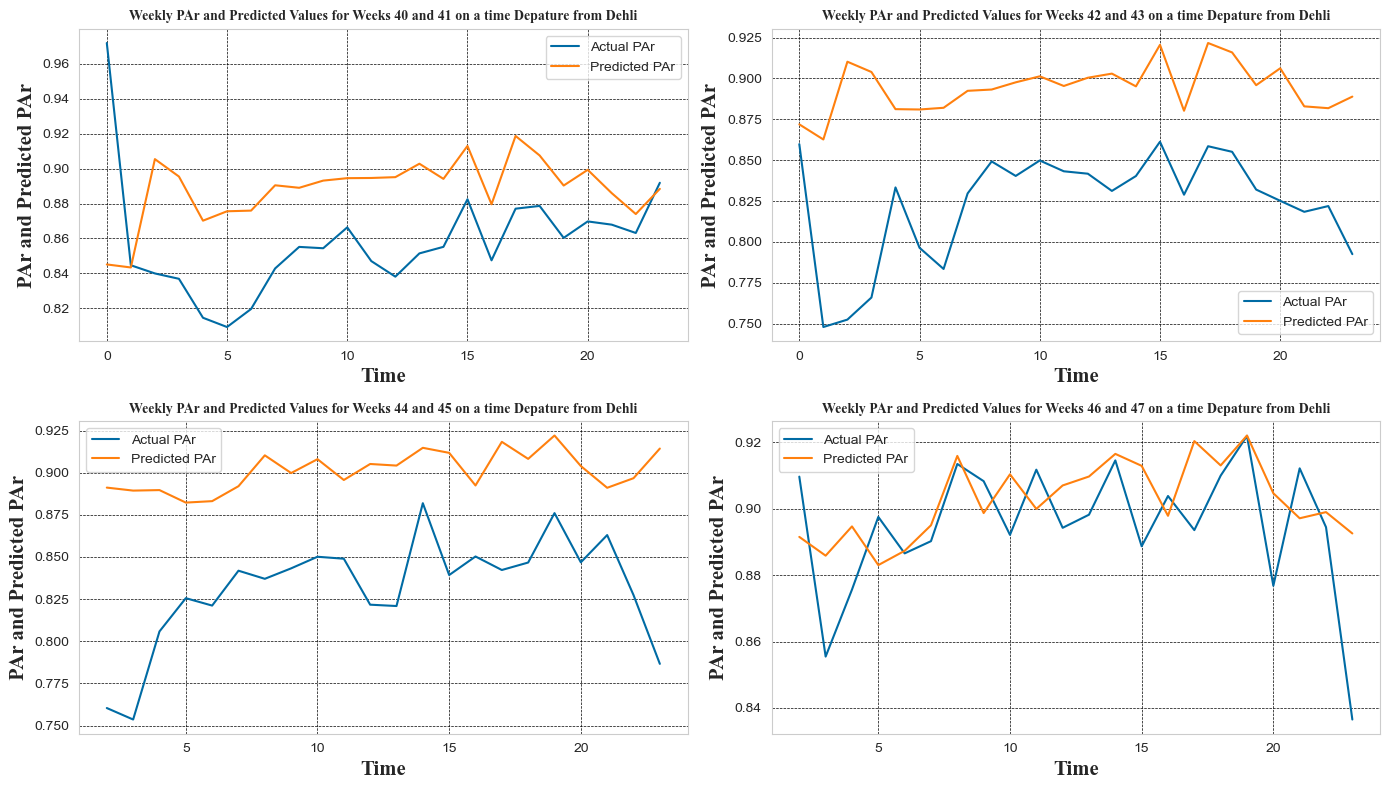

In [780]:
# Create DataFrames for each week
XGB_Test_42 = XGB_Test.loc[(XGB_Test["WN"] == 40) | (XGB_Test["WN"] == 41), :]
XGB_Test_43 = XGB_Test.loc[(XGB_Test["WN"] == 42) | (XGB_Test["WN"] == 43), :]
XGB_Test_44 = XGB_Test.loc[(XGB_Test["WN"] == 44) | (XGB_Test["WN"] == 45), :]
XGB_Test_45 = XGB_Test.loc[(XGB_Test["WN"] == 46) | (XGB_Test["WN"] == 47), :]
# Create a 2x2 subplot grid
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 8))

# Iterate through subplots and plot data for each week
for i, df in enumerate([XGB_Test_42, XGB_Test_43, XGB_Test_44, XGB_Test_45]):
    # Convert columns to numeric (in case they are not already)
    df.loc[:, 'PAr'] = pd.to_numeric(df['PAr'], errors='coerce')
    df.loc[:, 'Predicted PAr'] = pd.to_numeric(df['Predicted PAr'], errors='coerce')
    
    # Calculate subplot position in the 2x2 grid
    row = i // 2
    col = i % 2
    
    # Plotting the line graph on the current subplot
    sns.lineplot(x=df['Time'], y=df['PAr'], ax=axes[row, col], label='Actual PAr',errorbar=None)
    sns.lineplot(x=df['Time'], y=df['Predicted PAr'], ax=axes[row, col], label='Predicted PAr',errorbar=None)
    
    # Adding labels to axes
    axes[row, col].set_xlabel('Time',fontsize=15,fontname="Times New Roman", fontweight="bold")
    axes[row, col].set_ylabel('PAr and Predicted PAr',fontsize=15,fontname="Times New Roman", fontweight="bold")
    
     # Adding a title to the subplot
    week_start = df["WN"].values[0]
    week_end = week_start + 1
    axes[row, col].set_title(f'Weekly PAr and Predicted Values for Weeks {week_start} and {week_end} on a time Depature from Dehli', fontsize=10, fontname="Times New Roman", fontweight="bold")
    
    # Adding legend
    axes[row, col].legend()
    
    # Changing gridline color to black
    axes[row, col].grid(True, color='black', linestyle='--', linewidth=0.5)

# Adjust layout for better spacing
plt.tight_layout()
plt.savefig(r"C:\Users\enock.mugabi\AOBD_Historical_Data\DELI Pictures\Dehli_TimeInterval_Depature.png")
# Show the subplots
plt.show()

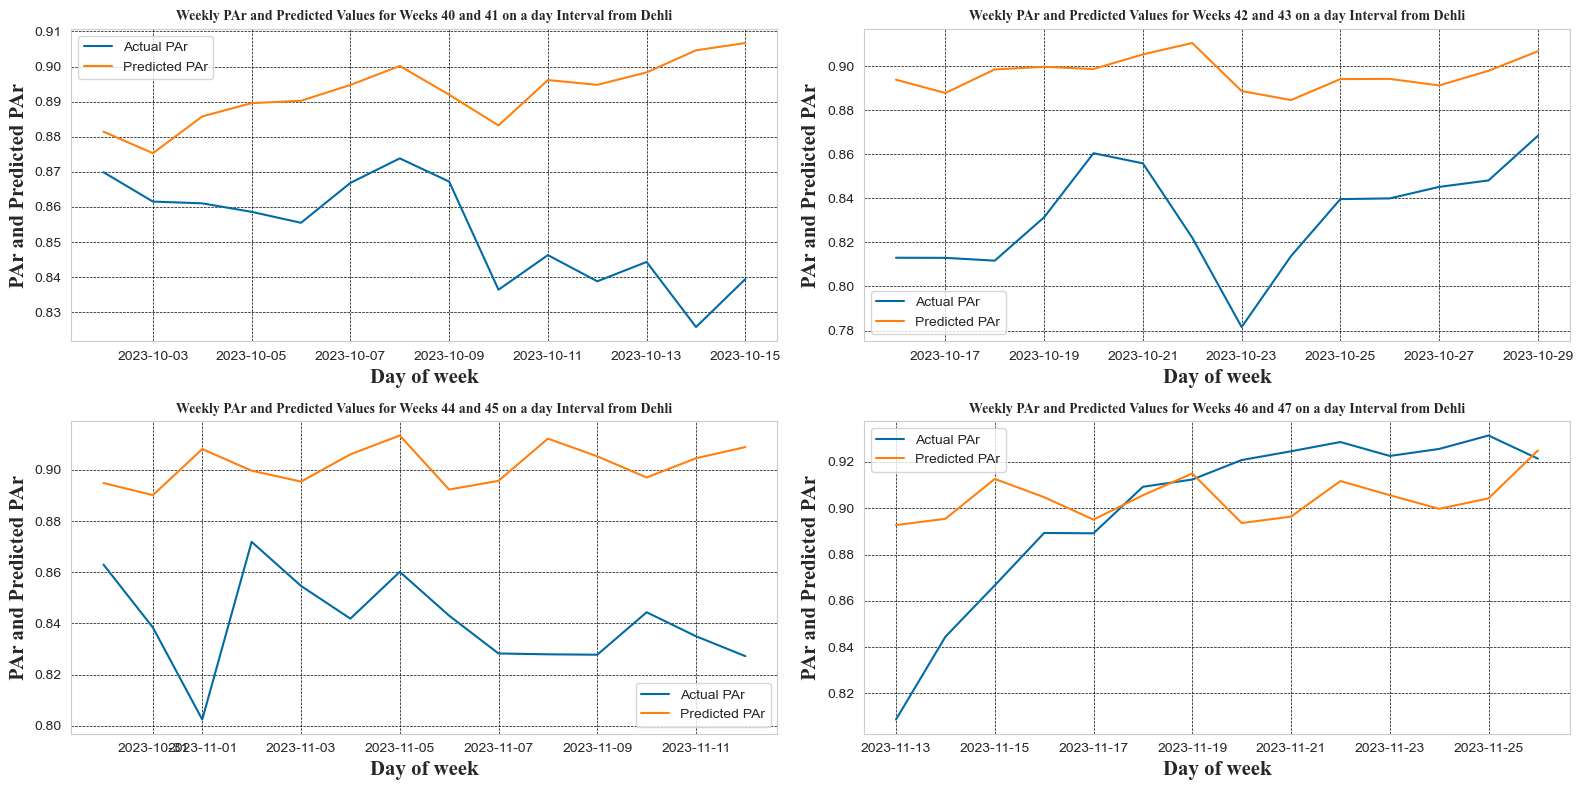

In [781]:
# Create DataFrames for each week
XGB_Test_42 = XGB_Test.loc[(XGB_Test["WN"] == 40) | (XGB_Test["WN"] == 41), :]
XGB_Test_43 = XGB_Test.loc[(XGB_Test["WN"] == 42) | (XGB_Test["WN"] == 43), :]
XGB_Test_44 = XGB_Test.loc[(XGB_Test["WN"] == 44) | (XGB_Test["WN"] == 45), :]
XGB_Test_45 = XGB_Test.loc[(XGB_Test["WN"] == 46) | (XGB_Test["WN"] == 47), :]

# Create a 2x2 subplot grid
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 8))

# Iterate through subplots and plot data for each week
for i, df in enumerate([XGB_Test_42, XGB_Test_43, XGB_Test_44, XGB_Test_45]):
    # Convert columns to numeric (in case they are not already)
    df.loc[:, 'PAr'] = pd.to_numeric(df['PAr'], errors='coerce')
    df.loc[:, 'Predicted PAr'] = pd.to_numeric(df['Predicted PAr'], errors='coerce')
    
    # Calculate subplot position in the 2x2 grid
    row = i // 2
    col = i % 2
    
    # Plotting the line graph on the current subplot
    sns.lineplot(x=df['Date'], y=df['PAr'], ax=axes[row, col], label='Actual PAr',errorbar=None)
    sns.lineplot(x=df['Date'], y=df['Predicted PAr'], ax=axes[row, col], label='Predicted PAr',errorbar=None)
    
    # Adding labels to axes
    axes[row, col].set_xlabel('Day of week',fontsize=15,fontname="Times New Roman", fontweight="bold")
    axes[row, col].set_ylabel('PAr and Predicted PAr',fontsize=15,fontname="Times New Roman", fontweight="bold")
    
     # Adding a title to the subplot
    week_start = df["WN"].values[0]
    week_end = week_start + 1
    axes[row, col].set_title(f'Weekly PAr and Predicted Values for Weeks {week_start} and {week_end} on a day Interval from Dehli', fontsize=10, fontname="Times New Roman", fontweight="bold")
    
    # Adding legend
    axes[row, col].legend()
    
    # Changing gridline color to black
    axes[row, col].grid(True, color='black', linestyle='--', linewidth=0.5)

# Adjust layout for better spacing
plt.tight_layout()
plt.savefig(r"C:\Users\enock.mugabi\AOBD_Historical_Data\DELI Pictures\Dehli_DayInterval_Depature.png")
# Show the subplots
plt.show()

#### Presentation using a whisker Box to graphically show the spread of a numerical variable through quartiles.

In [782]:
FR_PAr=XGB_Test["PAr"].describe()
FR_PAr=FR_PAr.reset_index()
FR_PAr_Predicted=XGB_Test["Predicted PAr"].describe()
FR_PAr_Predicted=FR_PAr_Predicted.reset_index()
Results_Summary=pd.merge(FR_PAr,FR_PAr_Predicted,on="index",how="inner")
Results_Summary

,index,PAr,Predicted PAr
0,count,33788.000000,33788.000000
1,mean,0.877570,0.902030
2,std,0.114309,0.052775
3,min,0.474138,0.593704
4,25%,0.818966,0.875169
5,50%,0.917582,0.906305
6,75%,0.963415,0.937569
7,max,0.996528,1.041838


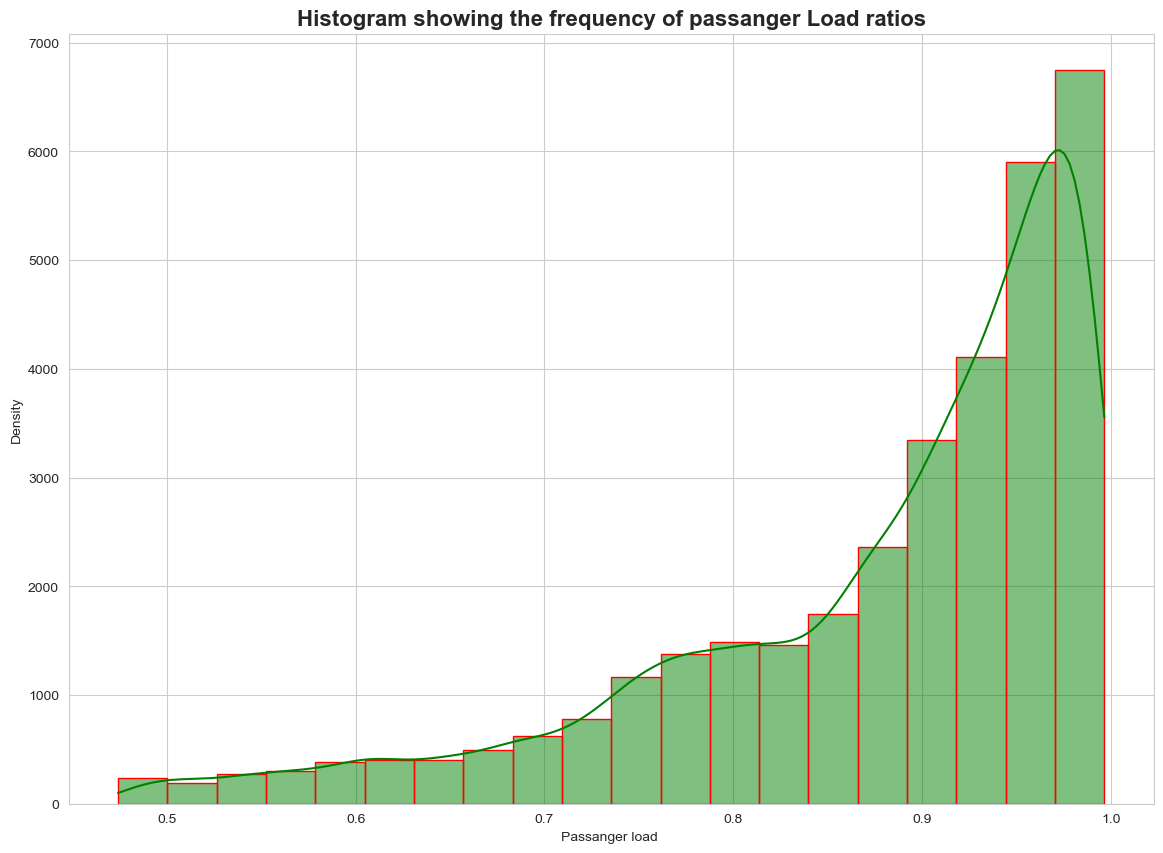

In [783]:
# Generate random data for the histogram
data = XGB_Test["PAr"]
 
# Creating a customized histogram with a density plot
sns.histplot(data, bins=20, kde=True, color='green', edgecolor='red')
 
# Adding labels and title
plt.xlabel('Passanger load ')
plt.ylabel('Density')
plt.title('Histogram showing the frequency of passanger Load ratios',fontsize="16",fontweight="bold")
 
plt.grid(True)
# Display the plot
plt.savefig(r"C:\Users\enock.mugabi\AOBD_Historical_Data\DELI Pictures\Hisgram_Dehli_Depatures_PAr.png")
plt.show()

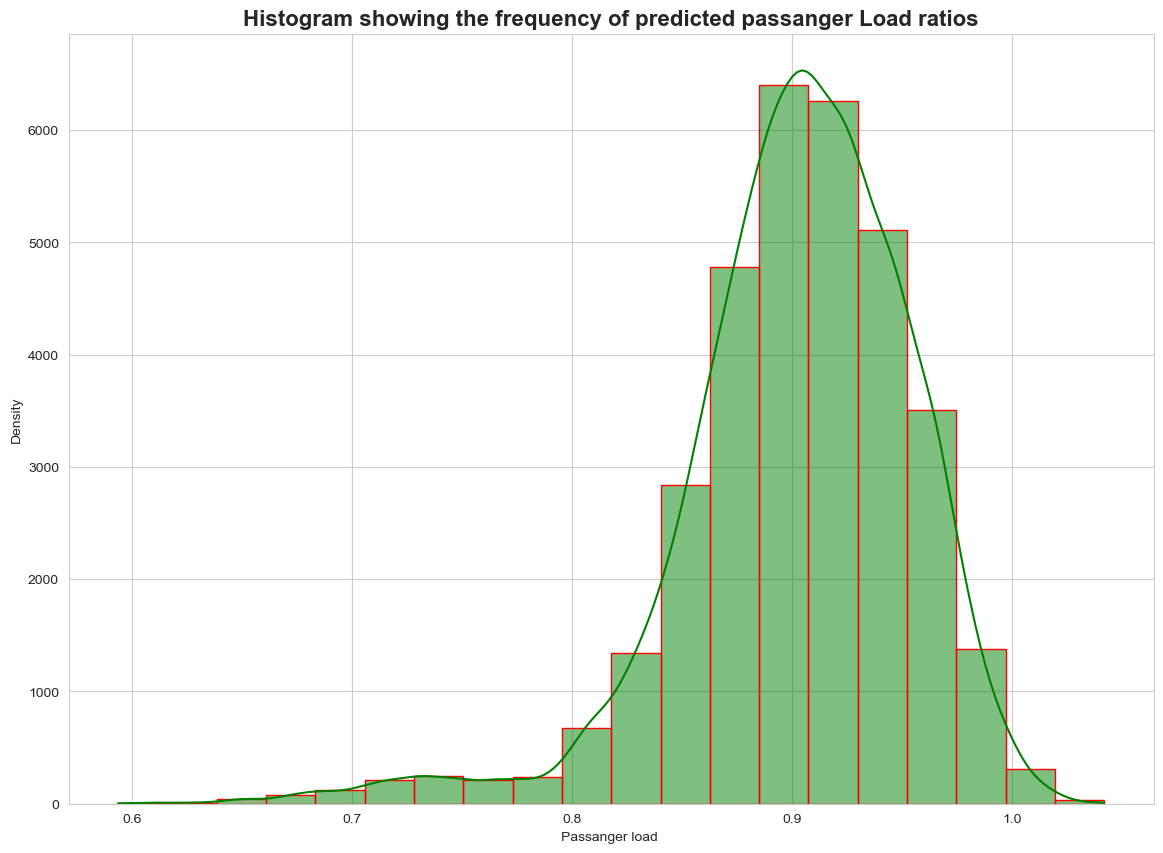

In [784]:
 # Generate random data for the histogram
data = XGB_Test["Predicted PAr"]
 
# Creating a customized histogram with a density plot
sns.histplot(data, bins=20, kde=True, color='green', edgecolor='red')
 
# Adding labels and title
plt.xlabel('Passanger load ')
plt.ylabel('Density')
plt.title('Histogram showing the frequency of predicted passanger Load ratios',fontsize="16",fontweight="bold")
 
plt.grid(True)
# Display the plot
plt.savefig(r"C:\Users\enock.mugabi\AOBD_Historical_Data\DELI Pictures\Hisgram_Dehli_Depatures_predictedPAr.png")
plt.show()

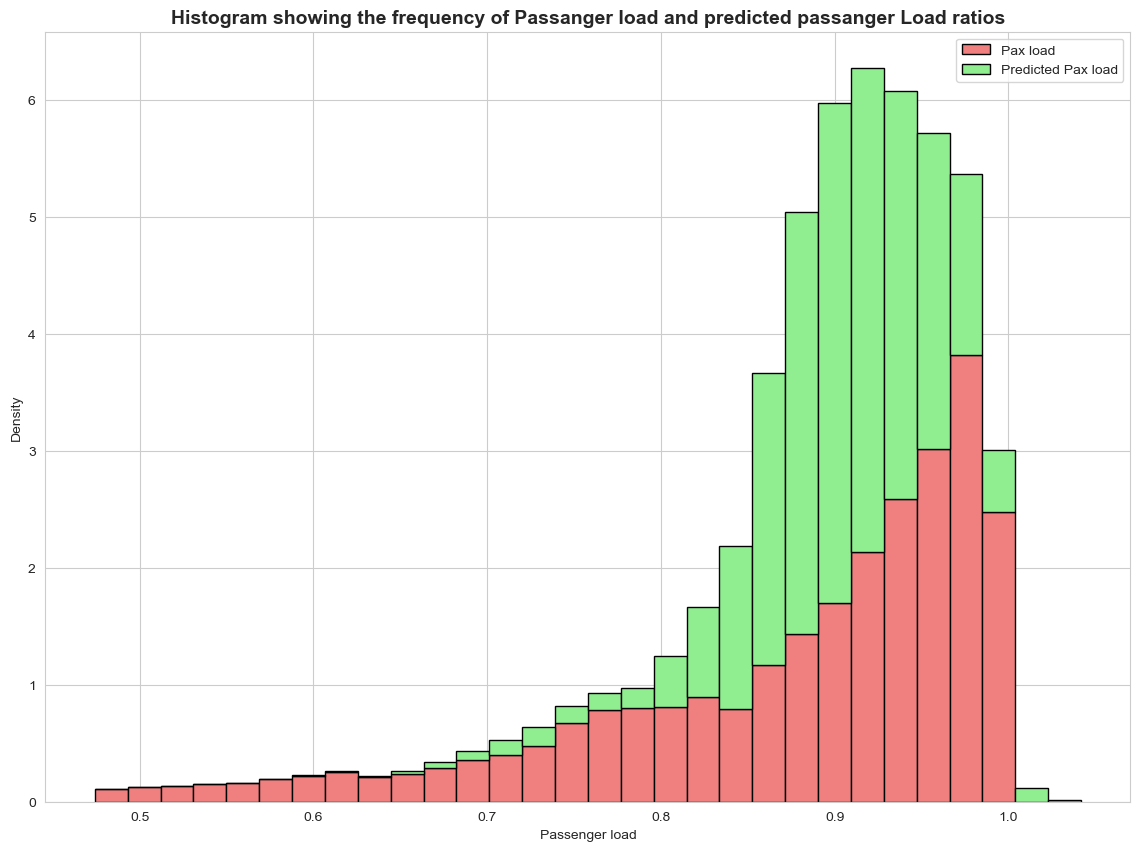

In [785]:
 import matplotlib.pyplot as plt

# Generate random data for the histogram
data_1 = XGB_Test["PAr"]
data_2 = XGB_Test["Predicted PAr"]

# Creating a customized histogram with a density plot
plt.hist([data_1, data_2], bins=30, stacked=True, color=['lightcoral', 'lightgreen'], edgecolor='black', density=True)
plt.title('Histogram showing the frequency of Passanger load and predicted passanger Load ratios',fontsize="14",fontweight="bold")
plt.xlabel('Passenger load')
plt.ylabel('Density')

# Adding legend
plt.legend(['Pax load', 'Predicted Pax load'])

plt.grid(True)
# Display the plot
plt.savefig(r"C:\Users\enock.mugabi\AOBD_Historical_Data\DELI Pictures\Hisgram_Dehli_Depatures.png")
plt.show()

In [786]:
XGB_Test=XGB_Test[["Date","WN","Time Interval","Destination airport","Flight Number","PAr","Predicted PAr"]]